In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math as mt
import plotly.express as px


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, cross_val_score,  cross_validate, GridSearchCV , validation_curve
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error,r2_score 
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import pickle

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score,roc_auc_score, roc_curve
from sklearn.metrics import RocCurveDisplay


import warnings
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


# Configurations:
pd.set_option('display.max_columns', 1500)
pd.set_option('display.float_format', lambda x: '%.6f' % x)
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1500)


In [2]:
churn = pd.read_csv("E:/MajorProject/telecom_customer_churn.csv") 
population = pd.read_csv("E:/MajorProject/telecom_zipcode_population.csv")

In [3]:
# Merge all tables for creating final data set:
 
df = churn.merge(population, on='Zip Code', how='left', suffixes=('', '_drop'))
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Population
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,NaN,Yes,42.390000,No,Yes,Cable,16.000000,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.600000,593.300000,0.000000,0,381.510000,974.810000,Stayed,NaN,NaN,4498
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,NaN,Yes,10.690000,Yes,Yes,Cable,10.000000,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.000000,542.400000,38.330000,10,96.210000,610.280000,Stayed,NaN,NaN,31297
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.650000,No,Yes,Fiber Optic,30.000000,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.900000,280.850000,0.000000,0,134.600000,415.450000,Churned,Competitor,Competitor had better devices,62069
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.820000,No,Yes,Fiber Optic,4.000000,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.000000,1237.850000,0.000000,0,361.660000,1599.510000,Churned,Dissatisfaction,Product dissatisfaction,46677
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,NaN,Yes,7.380000,No,Yes,Fiber Optic,11.000000,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.900000,267.400000,0.000000,0,22.140000,289.540000,Churned,Dissatisfaction,Network reliability,42853


In [4]:
df.shape

(7043, 39)

In [5]:
#Checking null value
df.isna().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

In [6]:
#Column with null value
cols_with_null = df.columns[df.isnull().any()].tolist()
cols_with_null

['Offer',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Internet Type',
 'Avg Monthly GB Download',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Churn Category',
 'Churn Reason']

#### Data Preprocessing: 

In [7]:
# filling 0.0 GB for customers with no internet service
df.loc[df['Internet Service'] == 'No', 'Avg Monthly GB Download'] = df.loc[df['Internet Service'] == 'No', 'Avg Monthly GB Download'].fillna(0.0)

In [8]:
# filling 0.0 Charges for customers with no phone services
df.loc[df['Phone Service'] == 'No', 'Avg Monthly Long Distance Charges'] = df.loc[df['Phone Service'] == 'No', 'Avg Monthly Long Distance Charges'].fillna(0.0)


In [9]:
# customers without internet service cannot have these services
net_dependent_features = ['Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data']
df.loc[df['Internet Service'] == 'No', net_dependent_features] = df.loc[df['Internet Service'] == 'No', net_dependent_features].fillna('No internet service')

In [10]:
# customers with no phone service cannot opt for multiple lines
df.loc[df['Phone Service'] == 'No', 'Multiple Lines'] = df.loc[df['Phone Service'] == 'No', 'Multiple Lines'].fillna('No phone service')

In [11]:
# assuming that some customers did not avail any offer
df['Offer'] = df['Offer'].fillna('No Offer')
print(df['Offer'].value_counts())

Offer
No Offer    3877
Offer B      824
Offer E      805
Offer D      602
Offer A      520
Offer C      415
Name: count, dtype: int64


In the above cells, we have imputed values for all columns except 'Churn Category' and 'Churn Reason'. These columns have a huge chunk of missing data and this can be attributed to the fact that not all customers fill such surveys. These columns aren't valuable from the perspective of training a classifier model since we already have the 'Customer Status' as our target variable, thus the most suitable course of action would be to drop these columns.

In [12]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                   0
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                        0
Internet Type                           0
Avg Monthly GB Download                 0
Online Security                         0
Online Backup                           0
Device Protection Plan                  0
Premium Tech Support                    0
Streaming TV                            0
Streaming Movies                  

We have successfully handled the missing values in all the columns after the data cleaning process. Now, let's move onto exploratory data analysis.

### Exploratory Data Analysis. 

In [13]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Scattergeo(
        lon = df['Longitude'],
        lat = df['Latitude'],
        text = df['Customer ID'],
        mode = 'markers',
        ))

fig.update_layout(
        title = 'Clients locations',
        geo_scope='usa',
    )
fig.update_geos(fitbounds="locations") 

The Customer ID column is not required for prediction. Also, the geographical features such as City, Zip Code, Latitude and Longitude do not effect our target variable much as we have seen during the EDA stage.

In [14]:
# These features will hinder the model's ability 
df = df.drop(columns=['Customer ID', 'Zip Code', 'Latitude', 'Longitude'])

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,7043.000000,46.509726,16.750352,19.000000,32.000000,46.000000,60.000000,80.000000
Number of Dependents,7043.000000,0.468692,0.962802,0.000000,0.000000,0.000000,0.000000,9.000000
Number of Referrals,7043.000000,1.951867,3.001199,0.000000,0.000000,0.000000,3.000000,11.000000
Tenure in Months,7043.000000,32.386767,24.542061,1.000000,9.000000,29.000000,55.000000,72.000000
Avg Monthly Long Distance Charges,7043.000000,22.958954,15.448113,0.000000,9.210000,22.890000,36.395000,49.990000
Avg Monthly GB Download,7043.000000,20.515405,20.418940,0.000000,3.000000,17.000000,27.000000,85.000000
Monthly Charge,7043.000000,63.596131,31.204743,-10.000000,30.400000,70.050000,89.750000,118.750000
Total Charges,7043.000000,2280.381264,2266.220462,18.800000,400.150000,1394.550000,3786.600000,8684.800000
Total Refunds,7043.000000,1.962182,7.902614,0.000000,0.000000,0.000000,0.000000,49.790000
Total Extra Data Charges,7043.000000,6.860713,25.104978,0.000000,0.000000,0.000000,0.000000,150.000000


Key observations:

- Average Age: 46.5
- Average Number of Dependents: 0.5
- Average Number of Referrals: 1.9
- Median Number of Referrals: 0 (this indicates that at least 50% of the customers do not give referrals)
- Average Tenure in Months: 32 (2.66 years)

In [16]:
# analysing descriptive statistics for customers who have churned

df[df["Customer Status"] == "Churned"].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1869.000000,49.735688,17.604893,19.000000,35.000000,50.000000,65.000000,80.000000
Number of Dependents,1869.000000,0.118245,0.549902,0.000000,0.000000,0.000000,0.000000,7.000000
Number of Referrals,1869.000000,0.521134,1.094667,0.000000,0.000000,0.000000,1.000000,9.000000
Tenure in Months,1869.000000,17.979133,19.531123,1.000000,2.000000,10.000000,29.000000,72.000000
Avg Monthly Long Distance Charges,1869.000000,23.167635,15.409464,0.000000,9.500000,22.880000,36.360000,49.980000
Avg Monthly GB Download,1869.000000,22.175495,18.309123,0.000000,9.000000,19.000000,27.000000,85.000000
Monthly Charge,1869.000000,73.347592,26.373764,-10.000000,55.300000,79.500000,94.200000,118.350000
Total Charges,1869.000000,1531.796094,1890.822994,18.850000,134.500000,703.550000,2331.300000,8684.800000
Total Refunds,1869.000000,1.518983,7.041632,0.000000,0.000000,0.000000,0.000000,49.570000
Total Extra Data Charges,1869.000000,7.158909,24.857342,0.000000,0.000000,0.000000,0.000000,150.000000


Key observations:

- Average Age: 49.7
- Average Number of Dependents: 0.1
- Average Number of Referrals: 0.5
- Median Number of Referrals: 0
- Average Tenure in Months: 17 (1.4 years)

Conclusions:

- Average Age seems to be slightly higher for churned customers
- Average Number of Dependents is significantly lower for churned customers
- Average Number of Referrals is significantly lower for churned customers. This seems logical as the reason for churn is most often that the product was not satisfactory, hence the customer would not recommend the product to others
- Average Tenure in Months is significantly lower. Again, expected.

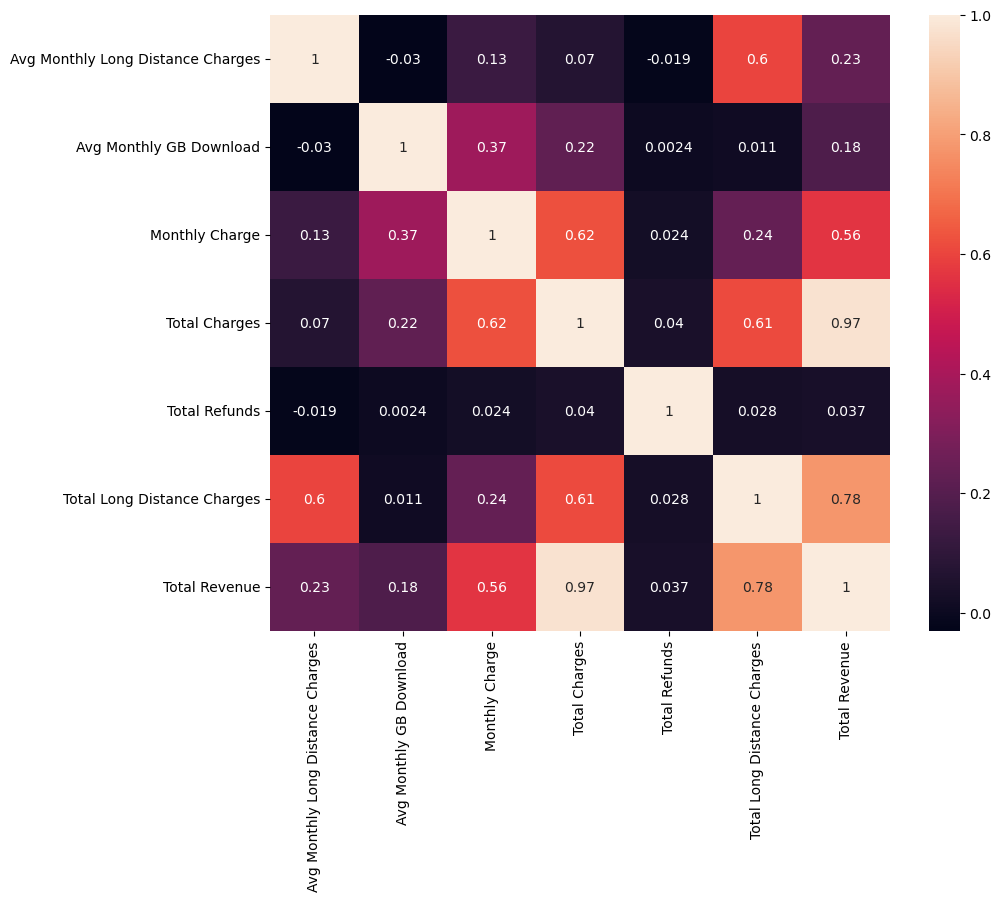

In [17]:
#Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[[col for col in df.columns if df[col].dtype == np.number]].corr(), annot=True)
plt.show()

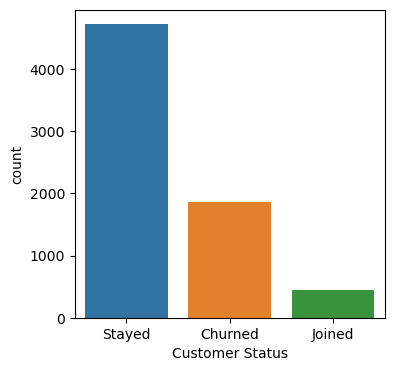

In [18]:
plt.figure(figsize=(4,4))
sns.countplot(data=df, x='Customer Status')
plt.show()

In [19]:
#Value of above graph
counts_Customer_Status = df["Customer Status"].value_counts()
counts_Customer_Status

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

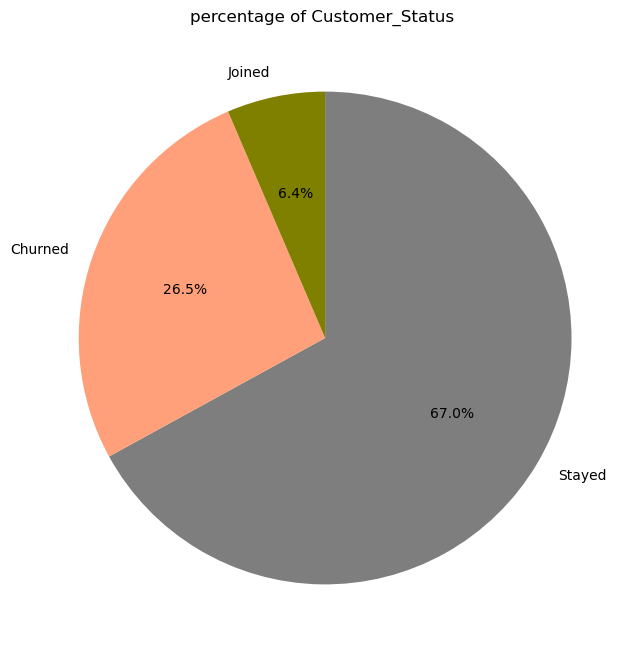

In [20]:
#Pie chart for above:
plt.rcParams["figure.figsize"] = (13,8)
mycolors = ["#7E7E7E", "#FFA07A", "#808000"]

def pie(pie_data,mycolors,title):
    plt.title(title)
    plt.pie(pie_data,labels = pie_data.index, startangle = 90, counterclock = False , autopct='%.1f%%',colors= mycolors)
pie(counts_Customer_Status,mycolors,"percentage of Customer_Status ")    

Observation: It's shown that 26.5% of the clients are churned at this data frame. We are going to remove the Joined Catagories because it doen't provide us any information about the churn rate.

Customers who have just availed the services are not an accurate representation of how long time customers feel about the company. In order to weed out this bias, we will drop the customers who have just joined.

In [21]:
#Removing Joined rows as it is cause misleading 
df = df[df["Customer Status"]!= "Joined"]
len(df)

6589

In [22]:
df['Customer Status'][df['Customer Status'] == 'Churned'].groupby(df['Gender']).count()

Gender
Female    939
Male      930
Name: Customer Status, dtype: int64

In [23]:
df['Customer Status'][df['Customer Status'] == 'Stayed'].groupby(df['Gender']).count()

Gender
Female    2338
Male      2382
Name: Customer Status, dtype: int64

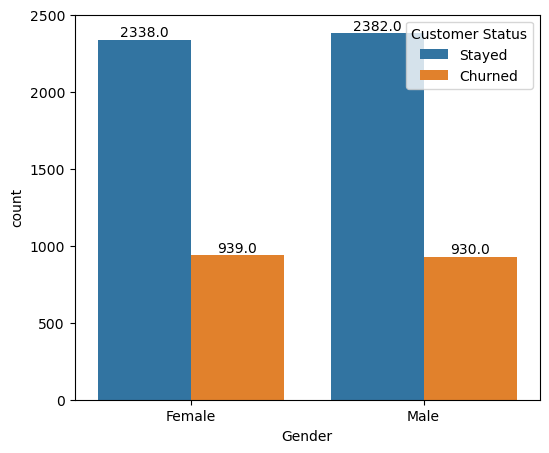

In [24]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x='Gender', hue='Customer Status')

# Adding count values on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

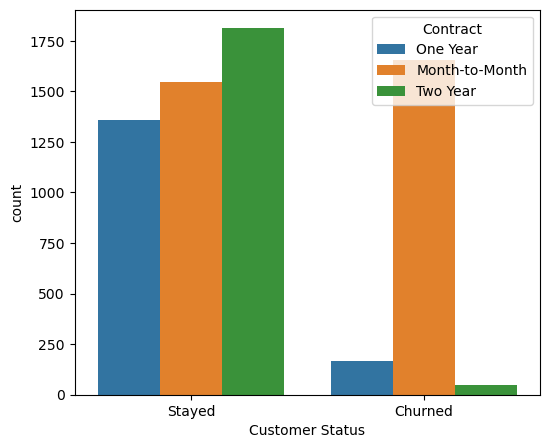

In [25]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Customer Status', hue='Contract')
plt.show()

### Exploring Chrun Reasons 

<Axes: xlabel='count', ylabel='Churn Category'>

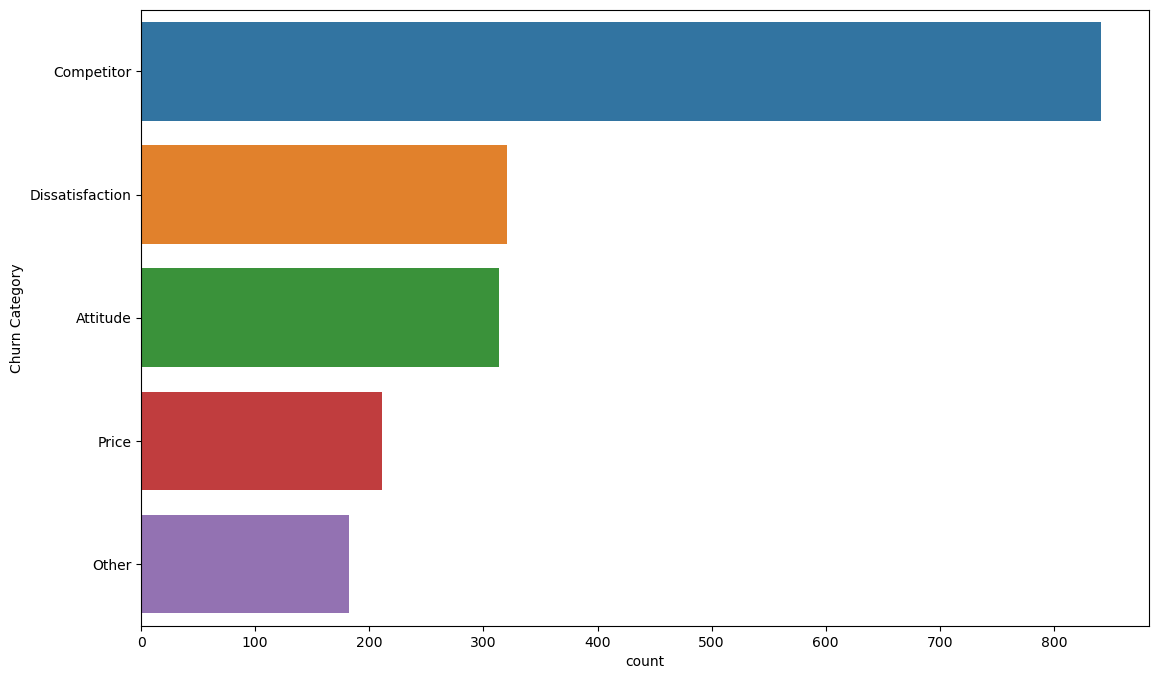

In [26]:
sns.countplot(data=df,y="Churn Category",order = df["Churn Category"].value_counts().index)

Observation: Apparently, main reason for church is that the company is not able to compete with opponent companies. If we check price reasoned churn, that does not seem to affect that much. So reason for general churn seems dissatisfaction from product and employee misbehavior. In order to gain back churned customers, company needs to pay attention to this factors. Factors like dissatisfaction and attitude composes "competitor" reason mostly. Few adjustment should be done.

In [27]:
#Value of above
df["Churn Category"].value_counts()

Churn Category
Competitor         841
Dissatisfaction    321
Attitude           314
Price              211
Other              182
Name: count, dtype: int64

Observation: It's clear that the reason of "competitor" was the most frequent

<Axes: xlabel='count', ylabel='Churn Reason'>

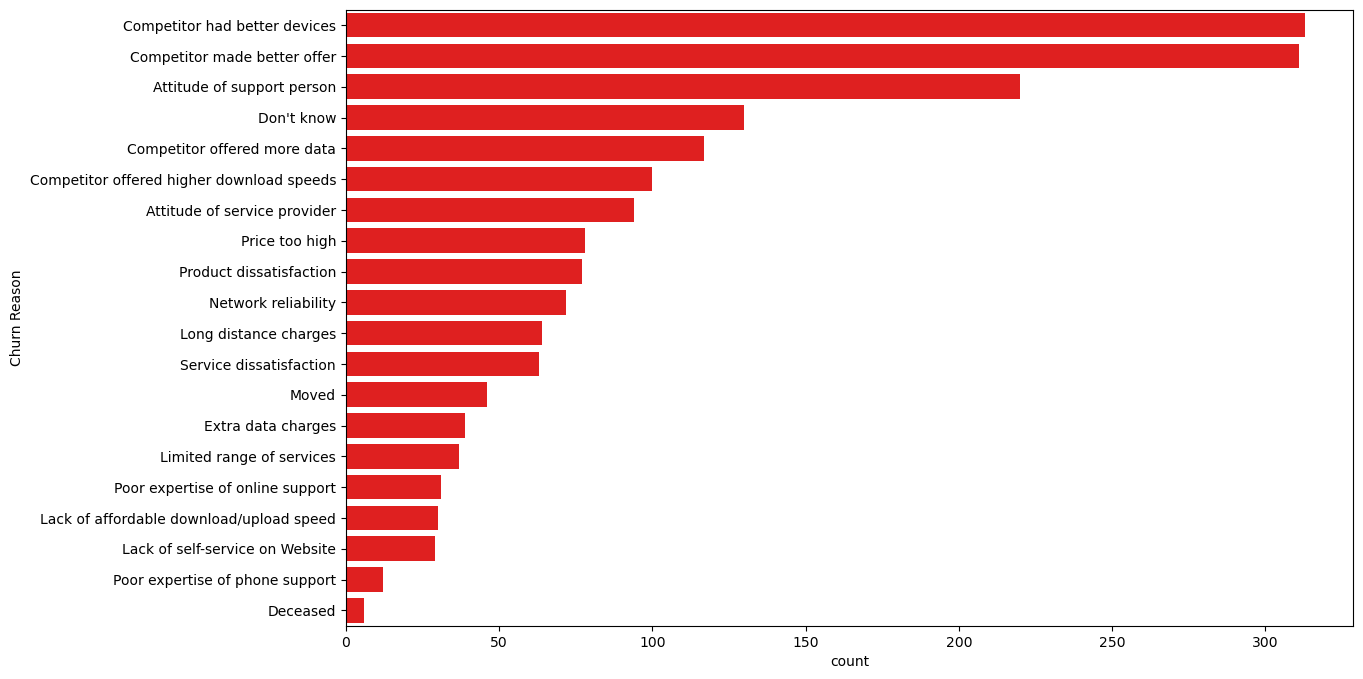

In [28]:
sns.countplot(data=df,y="Churn Reason",order = df["Churn Reason"].value_counts().index,color = 'red')

From these 2 plots we can start to have an idea about the Customer Churn Reasons so Most of the churn was because that :

- The competitor had better offers and technologie in general
- This company had a bad Attitude and Service
- This company charged a lot
- by exploring the reason for leaving the company.It's found that competitor better devices and better offers and Attitude of support person were the most frequent.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


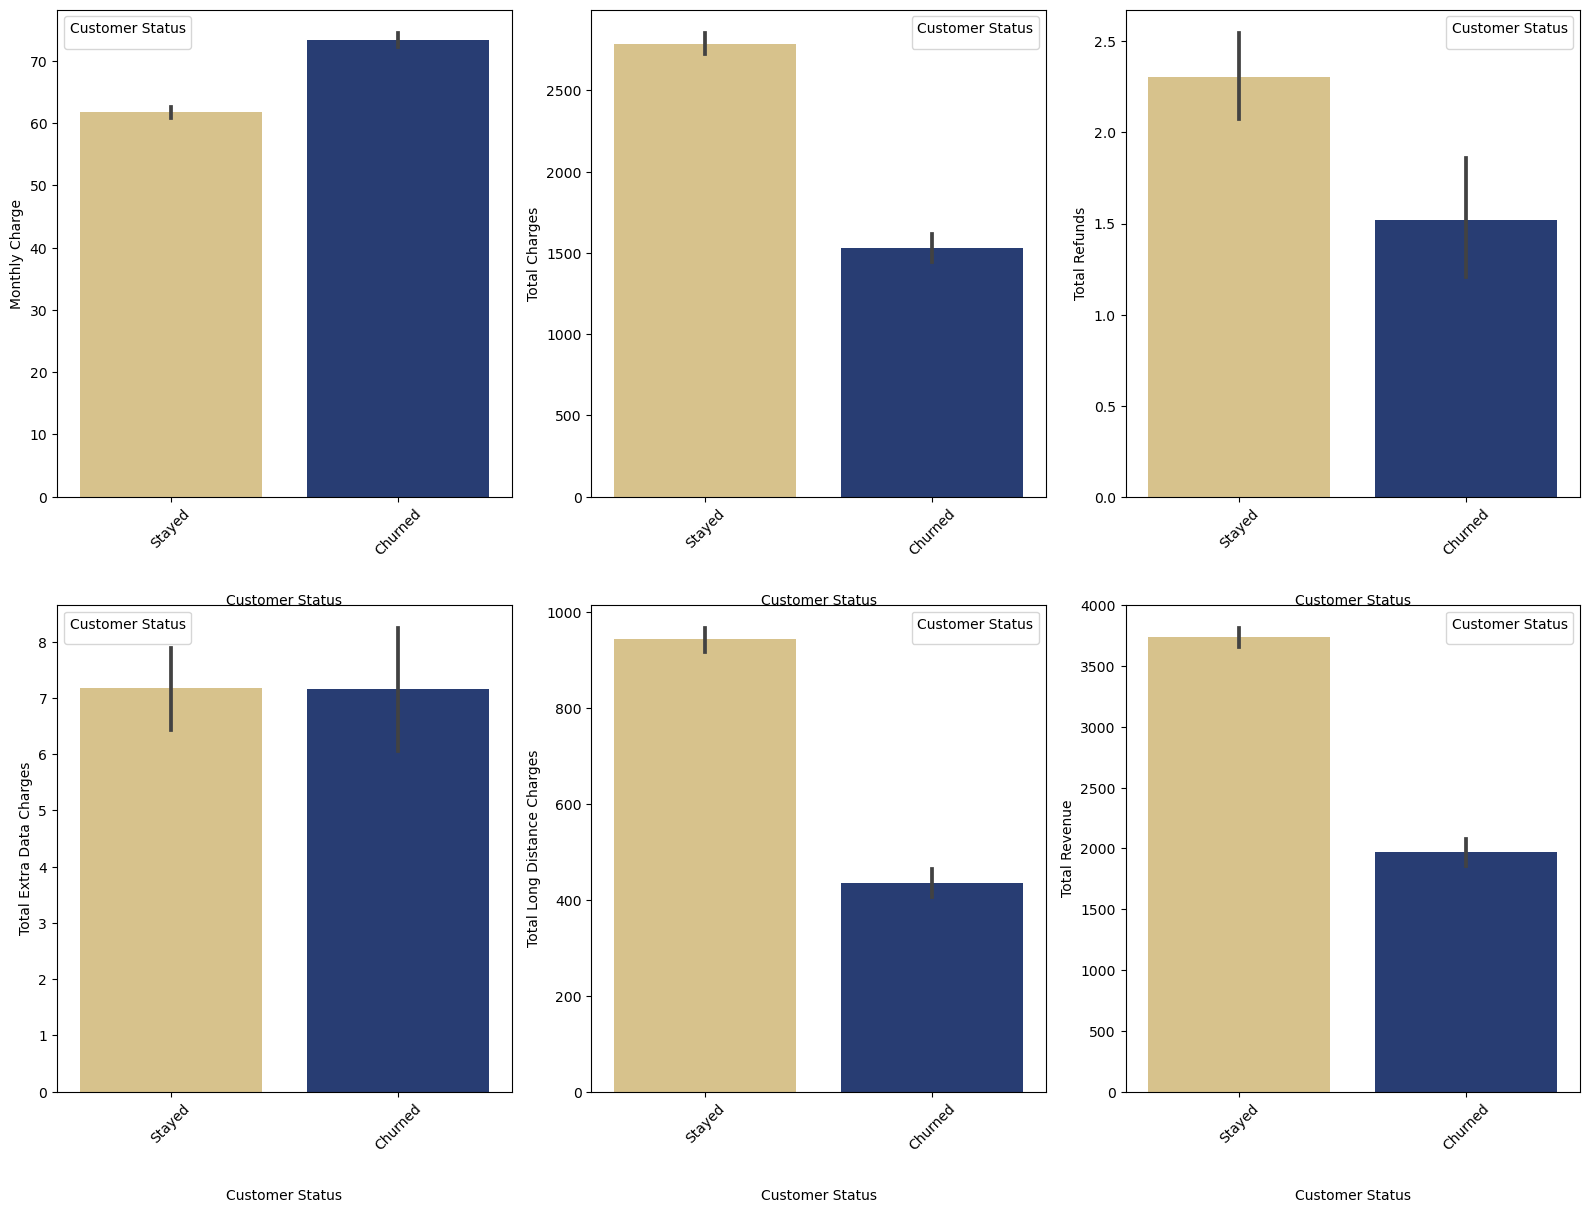

In [29]:
num1 = ["Monthly Charge", "Total Charges", "Total Refunds",
       "Total Extra Data Charges", "Total Long Distance Charges", "Total Revenue"]

fig, axes = plt.subplots(2, 3, figsize=(16, 12))
plt.subplots_adjust(wspace=0.3, hspace=0.5)
axes = axes.flatten()

colors = ["#e4c87f", "#1b3780"]  
for i in range(len(num1)):  # Iterate over the length of num1
    sns.barplot(x=df['Customer Status'], y=num1[i], data=df, ax=axes[i], palette=colors)
    axes[i].set_xlabel("Customer Status")
    axes[i].set_ylabel(num1[i])
    axes[i].legend(title="Customer Status")
    axes[i].set_xticklabels(df['Customer Status'].unique(), rotation=45)
    axes[i].xaxis.set_label_coords(0.5, -0.2)  
    axes[i].set_title("")
if len(num1) < 6:
    for i in range(len(num1), 6):
        axes[i].axis("off")

plt.tight_layout()
plt.show()


Observation: Based on these graphs, we can observe that Monthly Charge, Total Charges, Total Extra Data Charges, and Total Revenue have an impact on churn.

##### City Based 

Let us examine top 15 city that composes most of company revenue.

In [30]:
df_top_ten=df.groupby("City").sum().sort_values("Total Revenue",ascending=False).head(15)
df_top_ten["City"]=df_top_ten.index

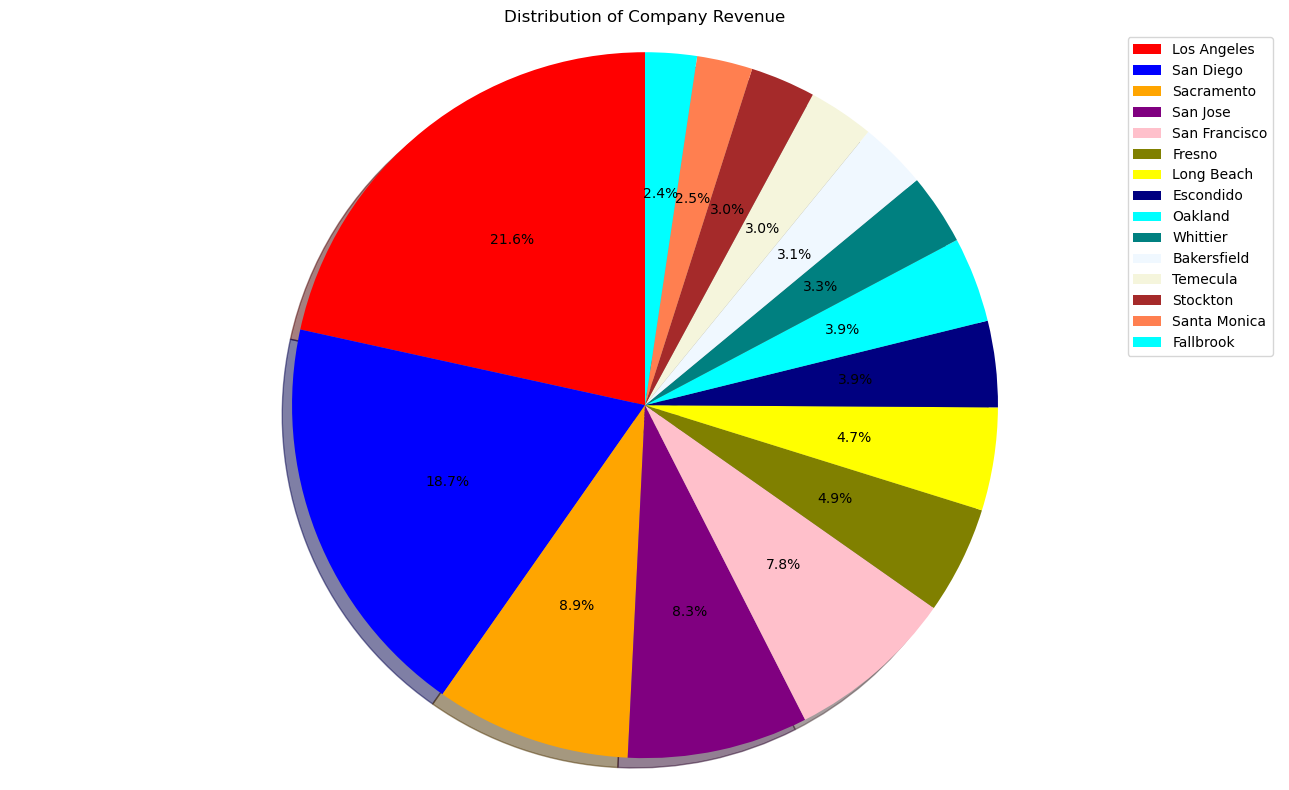

In [31]:
patches, texts, autotexts = plt.pie(
    df_top_ten["Total Revenue"],
    colors=["red", "blue", "orange", "purple", "pink", "olive", "yellow", "navy", "aqua", "teal", "aliceblue", "beige", "brown", "coral", "cyan", "green"],
    shadow=True,
    startangle=90,
    autopct='%1.1f%%'  # Display percentages with 1 decimal place
)

plt.legend(patches, df_top_ten["City"], loc="best")

plt.title("Distribution of Company Revenue")
plt.axis('equal')
plt.tight_layout()
plt.show()

You can see majority of revenue comes from Los Angeles, San Diego, Sacramento, San Jose and San Francisco. Let us examine churn situation of these countries.

In [32]:
df_top=df[df["City"].isin(["Los Angeles","San Diego", "Sacramento","San Jose","San Francisco"])]
fig= px.histogram(df_top, color="Customer Status",
            y='City',barmode='group',opacity=1, 
             height=700)
fig.show()


First of all, we can say that company is bleeding in San Diego. Certain precautions should be taken in this city. There are considerable churning numbers in there. Good news is marketing campaign are giving positive returns in biggest market which is LA. There is considerable amount of joining customers.

In [33]:
df_san=df[df["City"]=="San Diego"]
df_san=df_san[df_san["Customer Status"]=="Churned"]
df_san["Total Revenue"].sum()

385446.39

The revenue of the company from the people churned in this city is 385446$. Let us see why these people churned.

In [34]:

# Get value counts of the specified column
value_counts = df_san["Churn Category"].value_counts()

# Create DataFrame from value counts
df_reason_count = pd.DataFrame({"Reason": value_counts.index, "Count": value_counts.values})

# Display DataFrame
print(df_reason_count)


            Reason  Count
0       Competitor    152
1            Other     15
2         Attitude     10
3  Dissatisfaction      6
4            Price      2


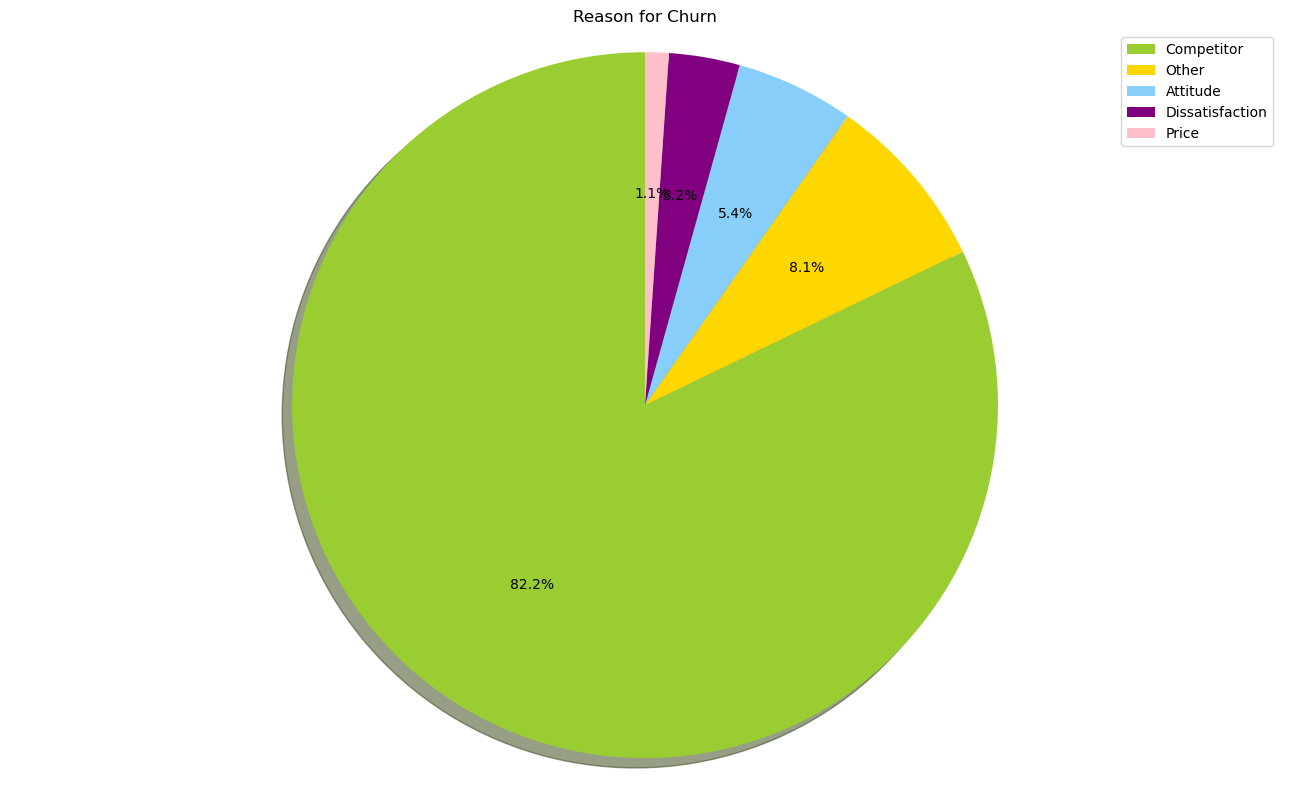

In [35]:
patches, texts, autotexts = plt.pie(
    df_reason_count["Count"],
    colors=['yellowgreen', 'gold', 'lightskyblue', 'purple', 'pink'],
    shadow=True,
    startangle=90,
    autopct='%1.1f%%'  # Display percentages with 1 decimal place
)

plt.legend(patches, df_reason_count["Reason"], loc="best")

plt.title("Reason for Churn")
plt.axis('equal')
plt.tight_layout()
plt.show()

You can see main reason for churn is competitor. Apparently certain competitor company has taken over the business from this company. Since this area has important part of the companys' total revenue, certain marketing campaign or discounts can be done in here.

### Numerical / Catagorical features

In [36]:
cat  = list(df.select_dtypes(include='object').columns)
num = list(df.select_dtypes(exclude='object').columns)

In [37]:
num

['Age',
 'Number of Dependents',
 'Number of Referrals',
 'Tenure in Months',
 'Avg Monthly Long Distance Charges',
 'Avg Monthly GB Download',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Population']

#### Numerical

##### Histogram plot

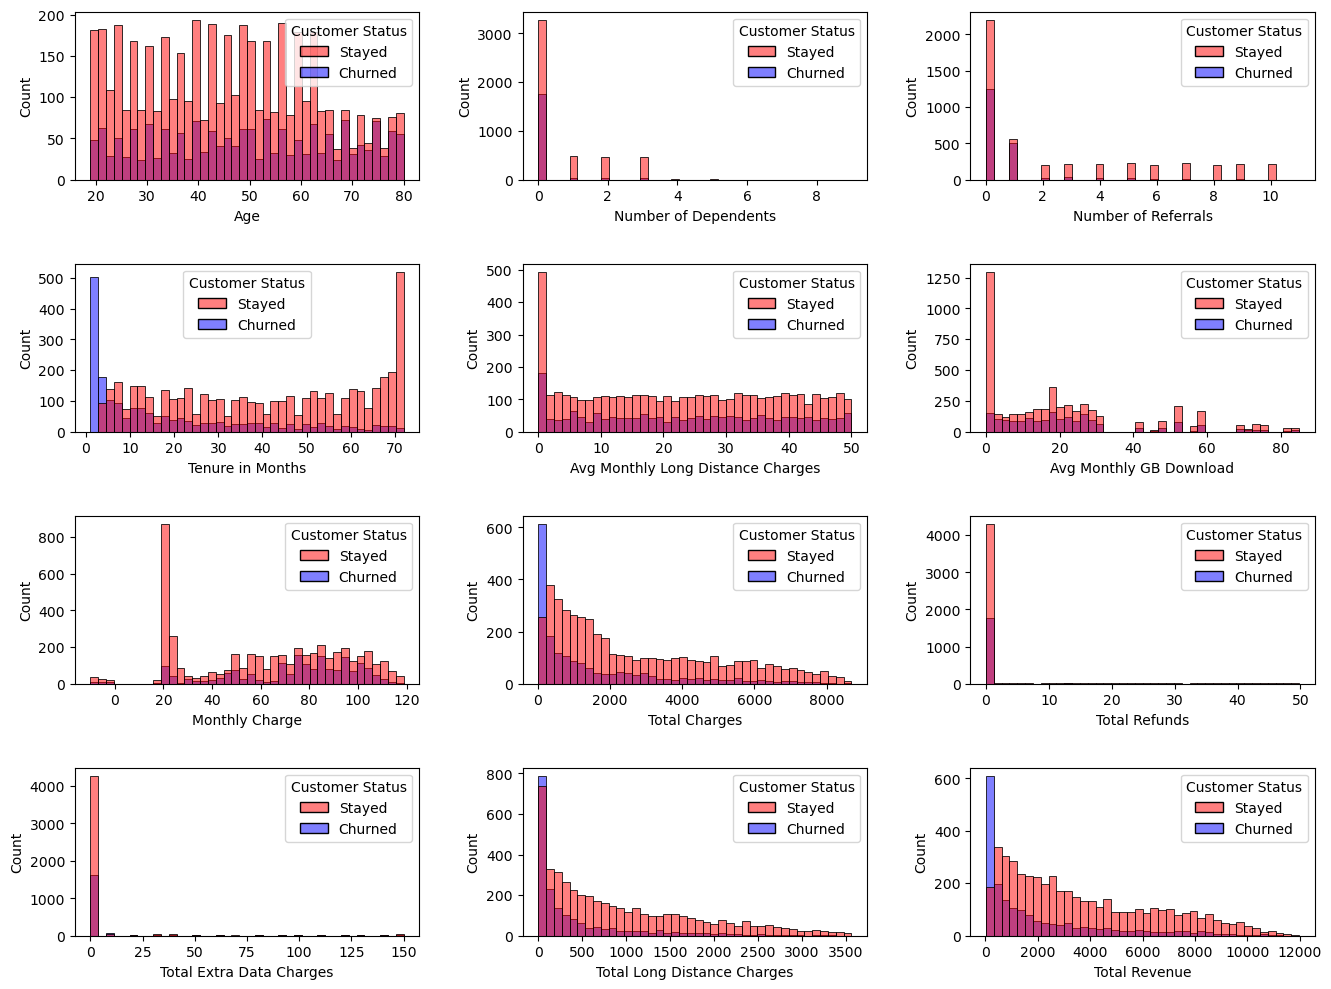

In [38]:

fig, axes = plt.subplots(4, 3, figsize=(16, 12))
plt.subplots_adjust(wspace=0.3, hspace=0.5)
axes = axes.flatten()

for i in range(min(len(num), len(axes))):
    sns.histplot(x=df[num[i]], hue=df['Customer Status'], palette=["red", "blue"], bins=40, ax=axes[i])


#### Summary for Numerical Features

We can notice that 3 features here strongly influence the churn rate

- Tensure in Months : A customer is more likely to churn in the first 4 months since he joined
- Total Charges We can notice that the amount of Total charge for churn customers is significantly lower than the Stayed in customers
- Total Revenue

##### Countplot

In [39]:
cat.remove("Churn Category")
cat.remove("Churn Reason")
cat.remove("City")

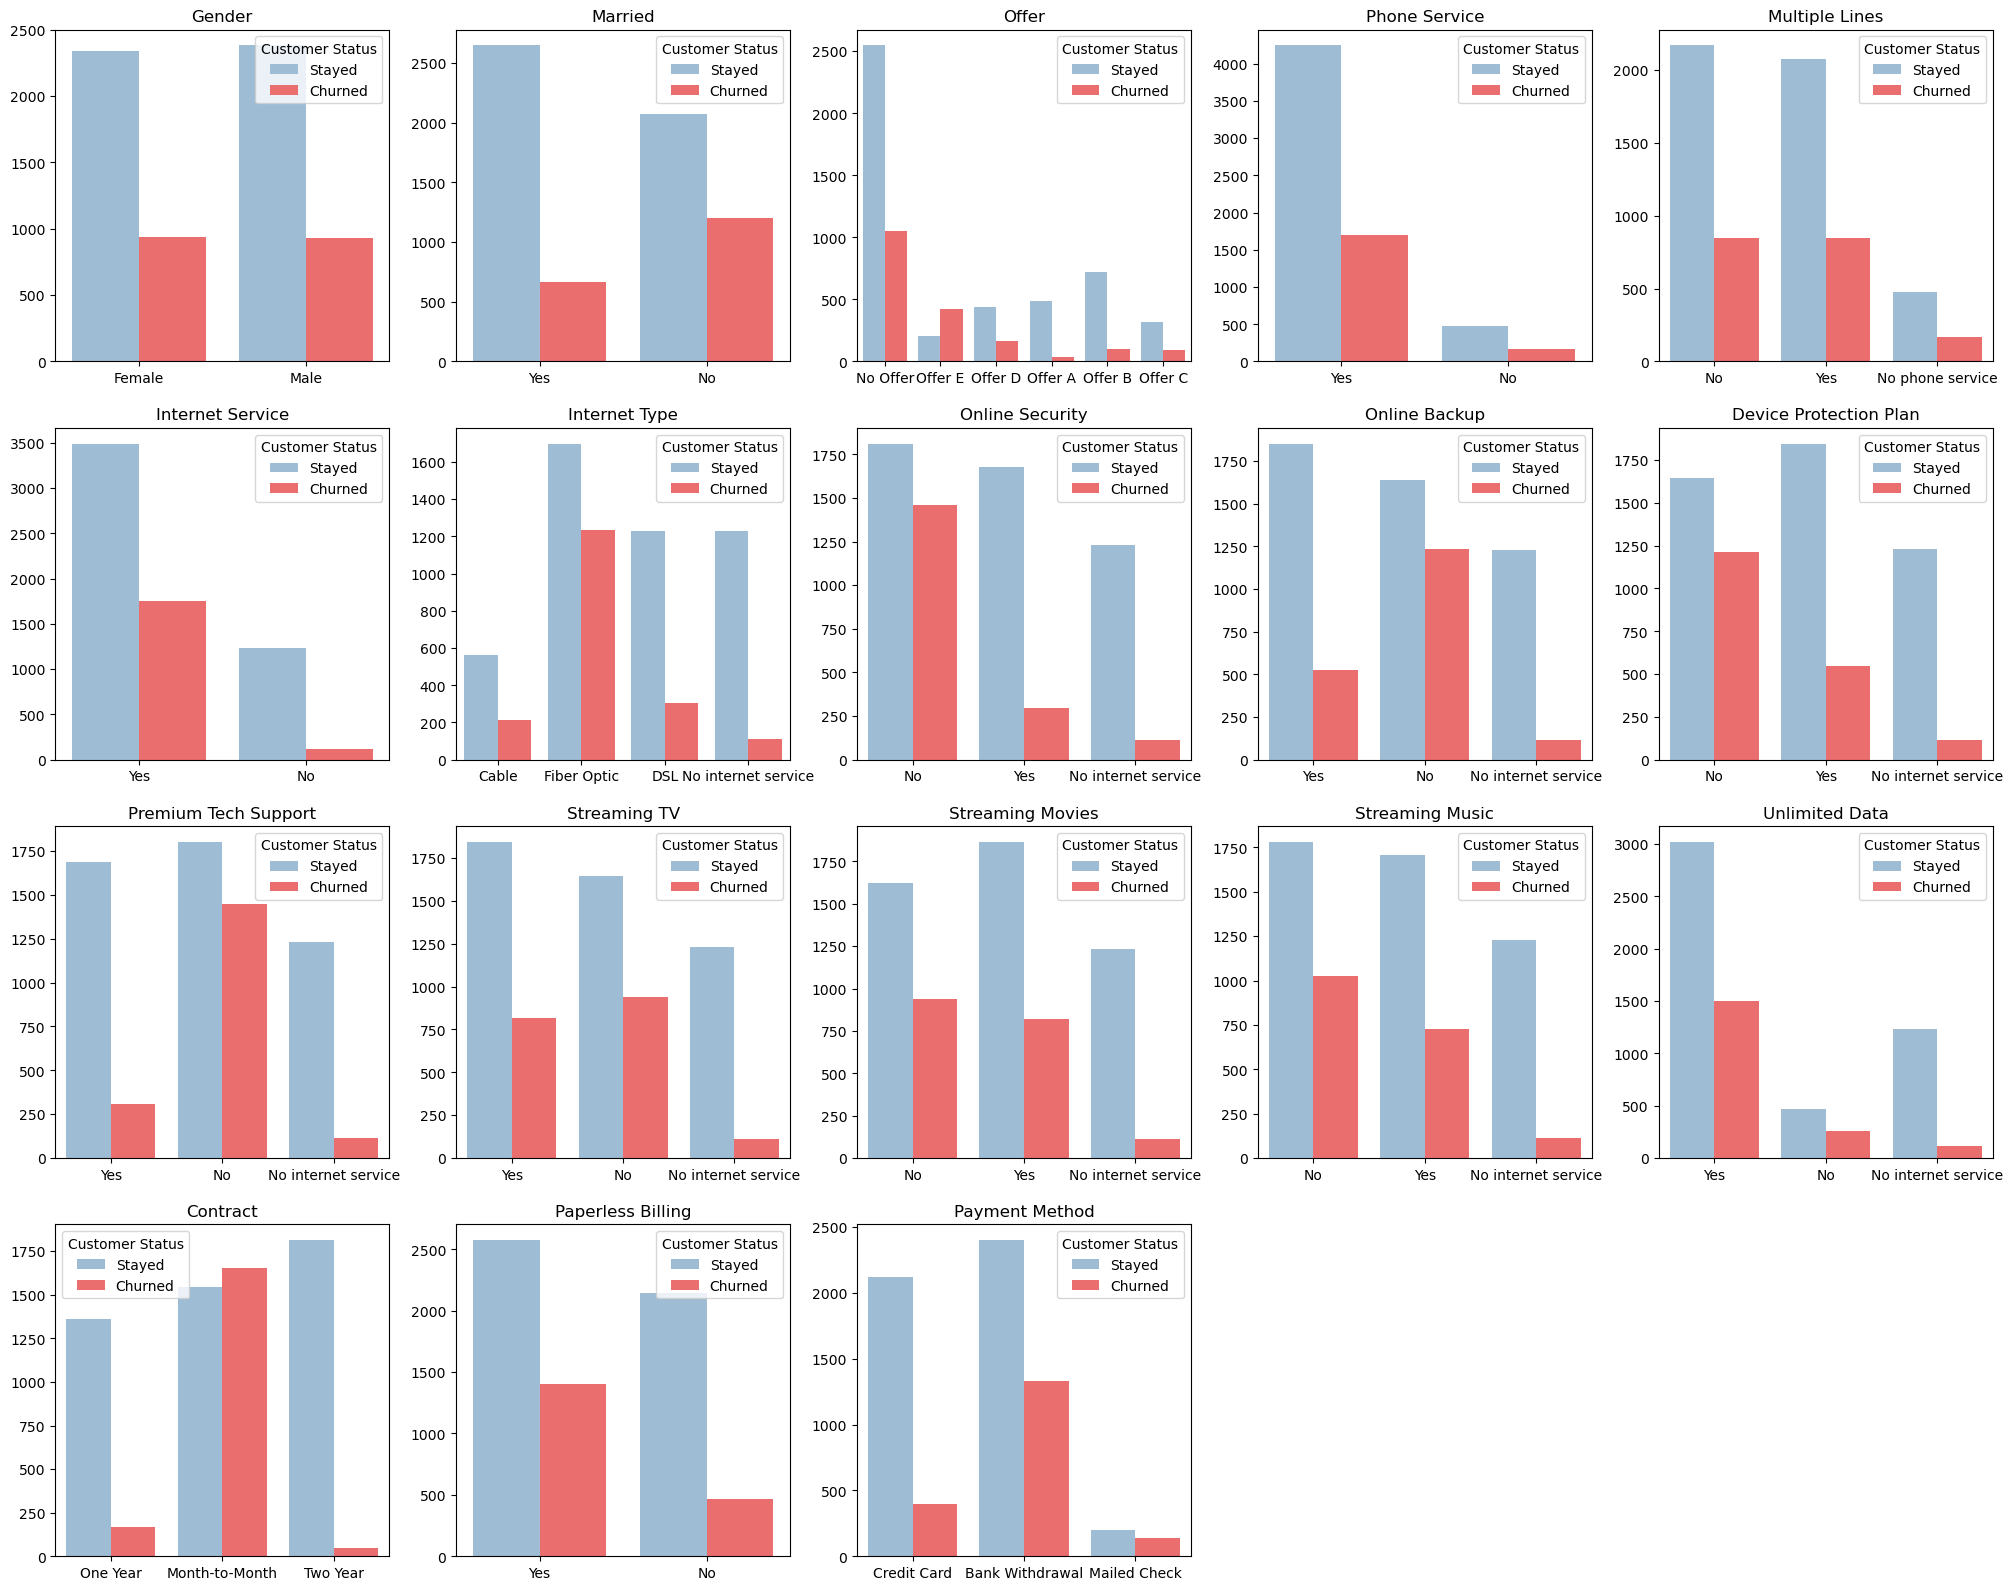

In [40]:
fig = plt.figure(figsize = (25, 25))
data_cat=df[cat]
i=1
for x in cat[:-1]:
    plt.subplot(5, 5, i)
    ax=sns.countplot(data =data_cat , x = data_cat[x], hue ='Customer Status', palette = ["#95BEDD", '#FF5959'])
    ax.set(xlabel = None, ylabel = None)
    plt.title(str(x), loc='center')
    i+=1
plt.show()


##### Line plot 

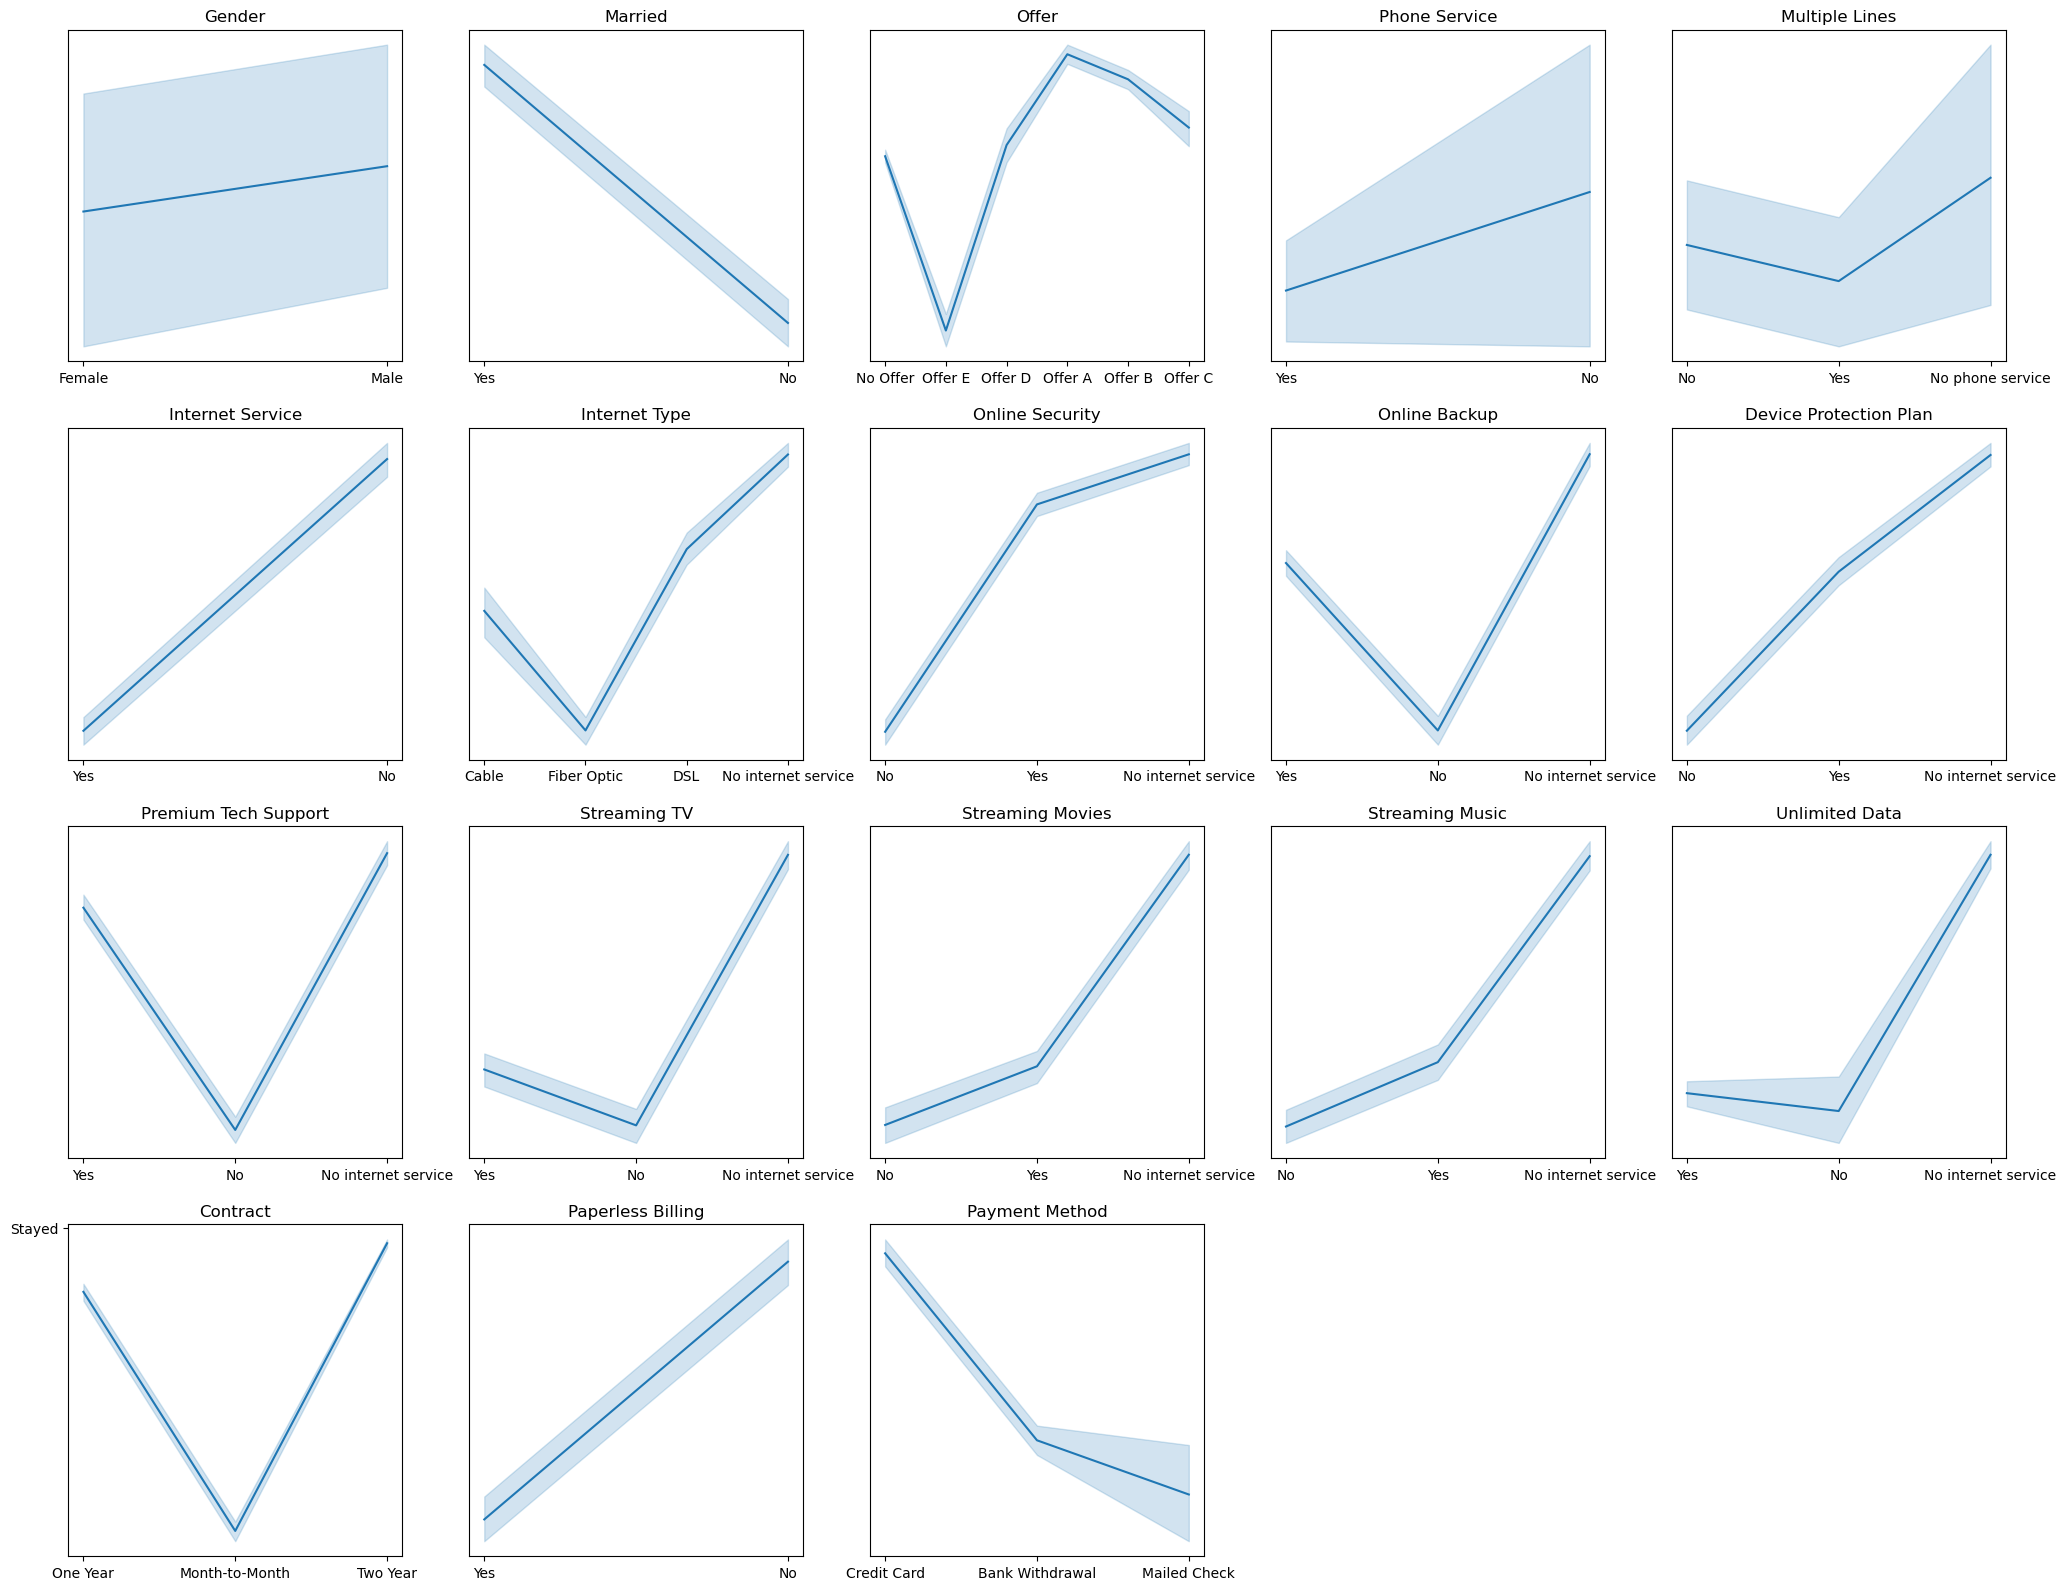

In [41]:
fig = plt.figure(figsize = (25, 25))
data_cat=df[cat]
i=1
for x in cat[:-1]:
    plt.subplot(5, 5, i)
    ax=sns.lineplot(data =data_cat , x = data_cat[x],y ='Customer Status')
    ax.set(xlabel = None, ylabel = None)
    plt.title(str(x), loc='center')
    i+=1
plt.show()

##### PieChart 

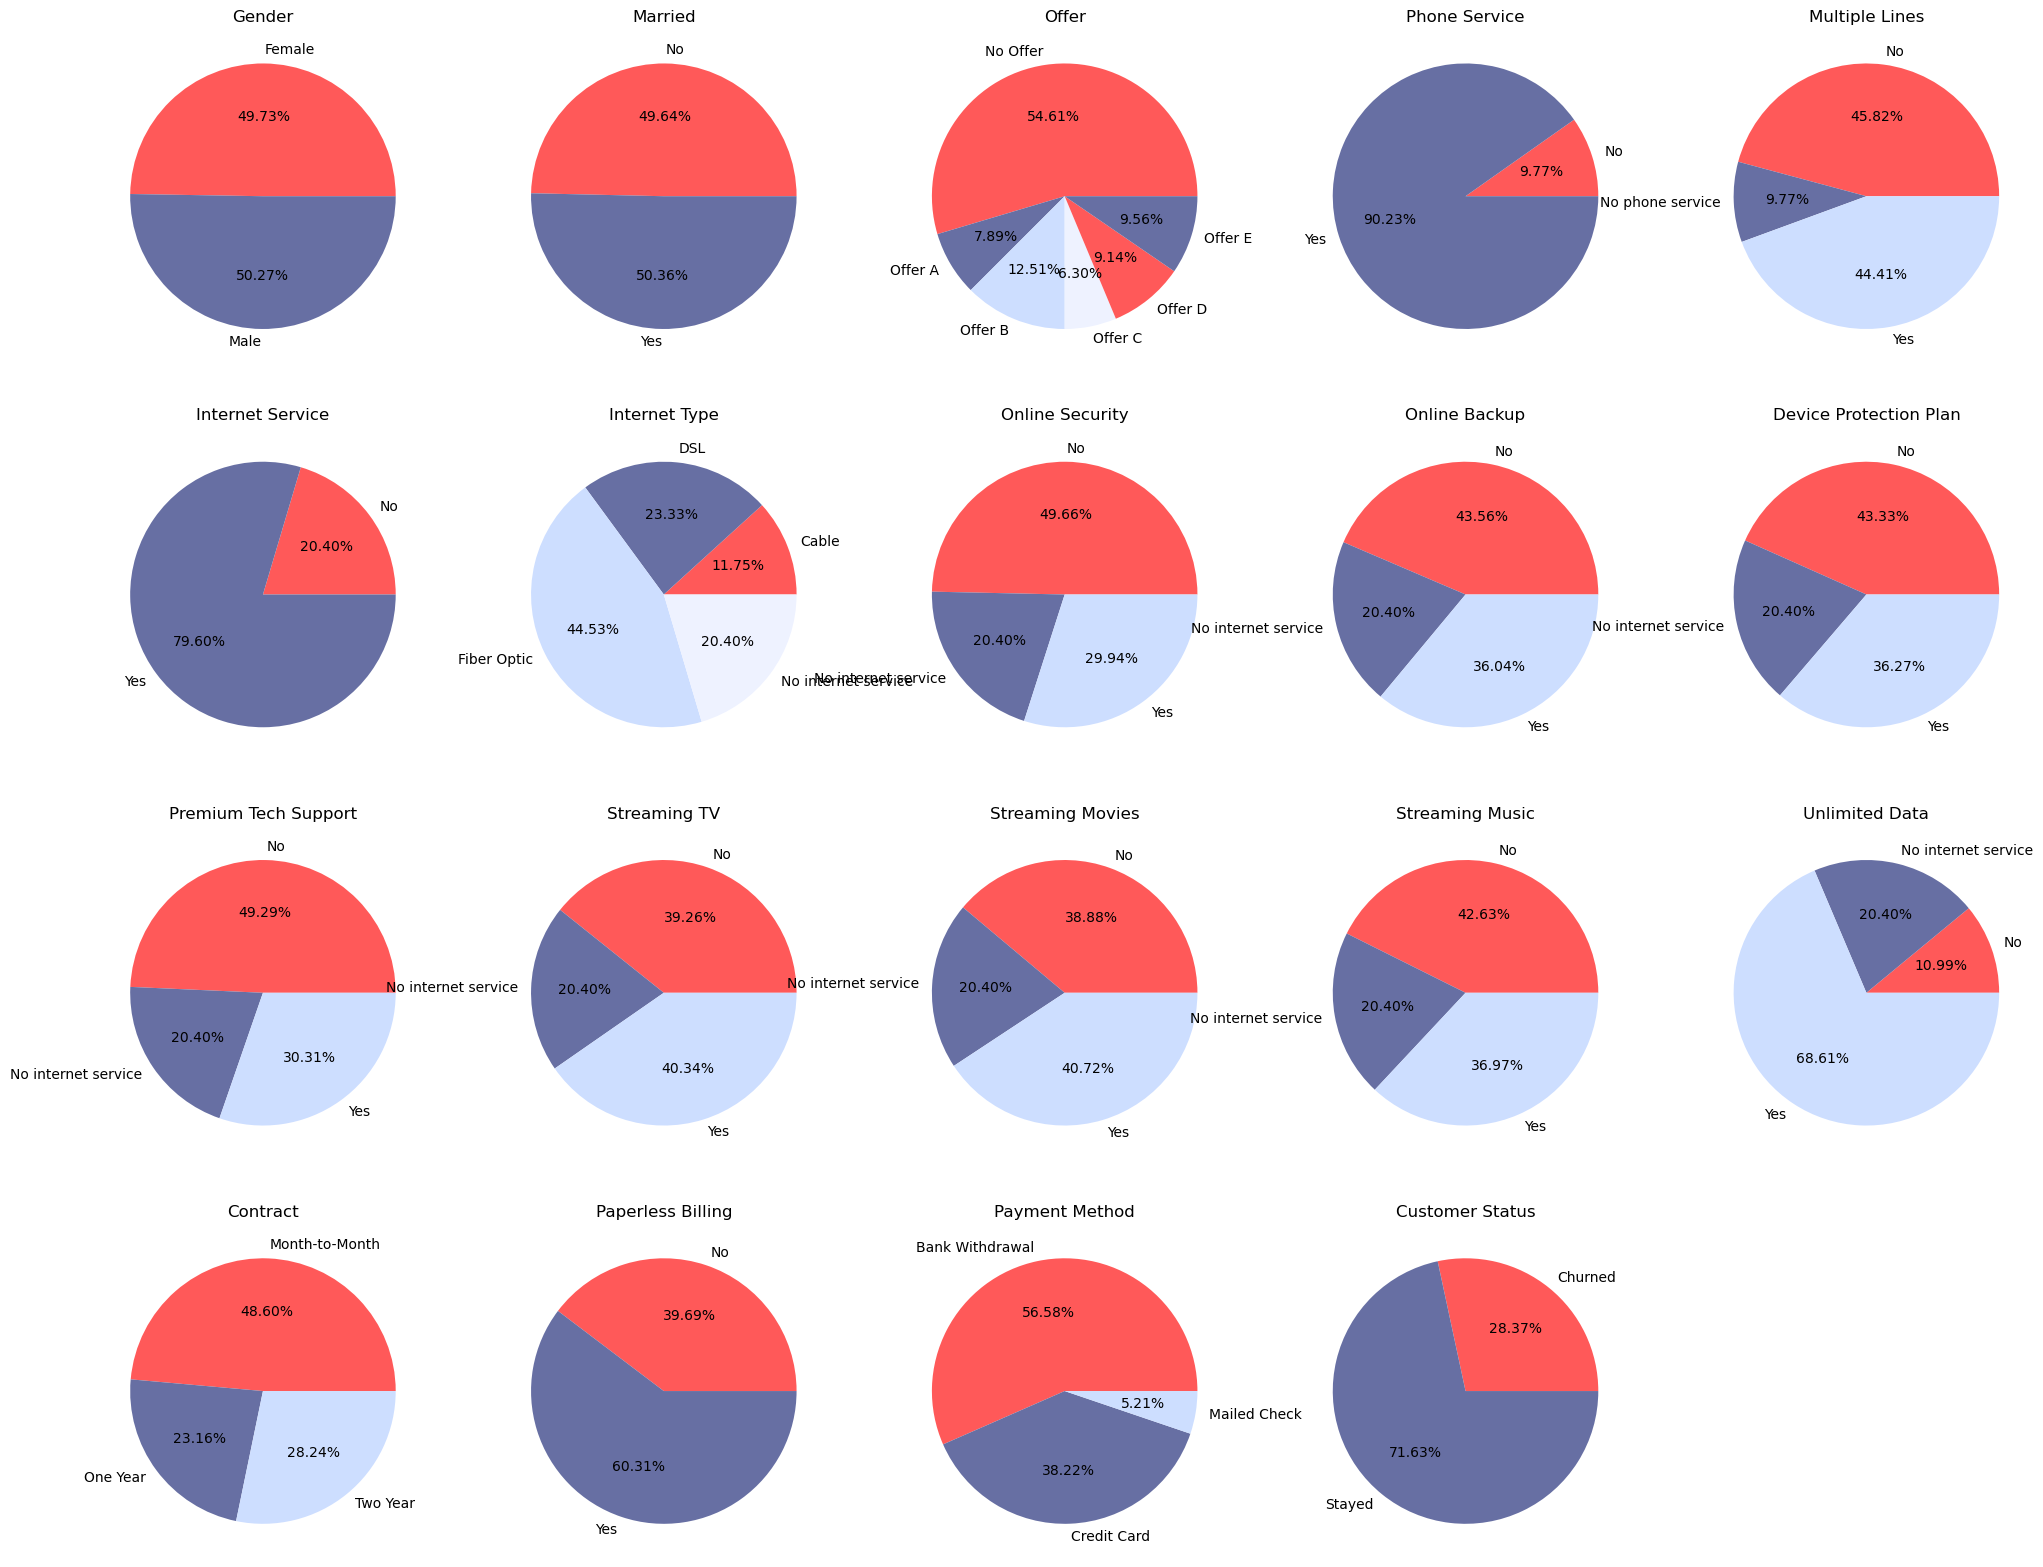

In [42]:
fig = plt.figure(figsize = (25, 25))
data_cat=df[cat]
i=1
for x in cat:
    plt.subplot(5, 5, i)
    ax = df.groupby([x]).size().plot(kind = 'pie', autopct = '%.2f%%', colors = ['#FF5959', '#676FA3','#CDDEFF', '#EEF2FF'])
    ax.set(xlabel = None, ylabel = None)
    plt.title(str(x), loc='center')
    i+=1
plt.show()

##### Summary For Catagorical Features 

We can notice that some feature are strongly responsible for this churn rate :

- Offer : Most clients didn't get any offer types which can be caused by the bad communication and service of the industry .Also we should have a look at the offer type E because it still has a bad churn rate
- Service : It looks like client who have either a phone service or an internet service are more likely to churn which reflectes the poor service
- Internet Type : The majorety of churn customers are FiberOptic clients
- Features : the customers who are enrolled in Online security, Online Backup,Device Protection Plan,Premium Tech Support, Unlimited Data are less likely to churn
- Contract : Clients with Monthly subscriptions and Bank Withdrawal are the most Churn of all others

#### Analysis Between High Value Customers and Churn Customers¶ 

##### High Value Clients Analysis¶

Customers who have provided revenue higher than the company's average and have maintained their engagement are regarded as valuable and loyal clients.

In [43]:
#finding mean value of there revenue
df['Total Revenue'].mean()

3235.2180816512373

In [44]:
# High value if above mean value
df['High Value'] = 0
df.loc[df['Total Revenue'] > 3235.2180816512373, 'High Value'] = 'High Value'

In [45]:
df_high_value = df[df['High Value'] == 'High Value']
df_high_value.head()

,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Population,High Value
6,Female,67,Yes,0,Lompoc,1,71,Offer A,Yes,9.960000,No,Yes,Fiber Optic,14.000000,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,Yes,Bank Withdrawal,109.700000,7904.250000,0.000000,0,707.160000,8611.410000,Stayed,NaN,NaN,6165,High Value
7,Male,52,Yes,0,Napa,8,63,Offer B,Yes,12.960000,Yes,Yes,Fiber Optic,7.000000,Yes,No,No,Yes,No,No,No,No,Two Year,Yes,Credit Card,84.650000,5377.800000,0.000000,20,816.480000,6214.280000,Stayed,NaN,NaN,63947,High Value
9,Female,43,Yes,1,Sheridan,3,65,No Offer,Yes,28.460000,Yes,Yes,Cable,14.000000,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,Yes,Credit Card,90.450000,5957.900000,0.000000,0,1849.900000,7807.800000,Stayed,NaN,NaN,1219,High Value
11,Female,25,Yes,2,Sunnyvale,2,72,No Offer,Yes,16.010000,Yes,Yes,Fiber Optic,59.000000,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Two Year,Yes,Credit Card,116.800000,8456.750000,0.000000,0,1152.720000,9609.470000,Stayed,NaN,NaN,64010,High Value
13,Female,32,No,0,La Mesa,0,72,Offer A,Yes,2.250000,Yes,Yes,Fiber Optic,16.000000,Yes,Yes,Yes,No,Yes,No,No,Yes,Two Year,Yes,Bank Withdrawal,101.300000,7261.250000,0.000000,0,162.000000,7423.250000,Stayed,NaN,NaN,24005,High Value


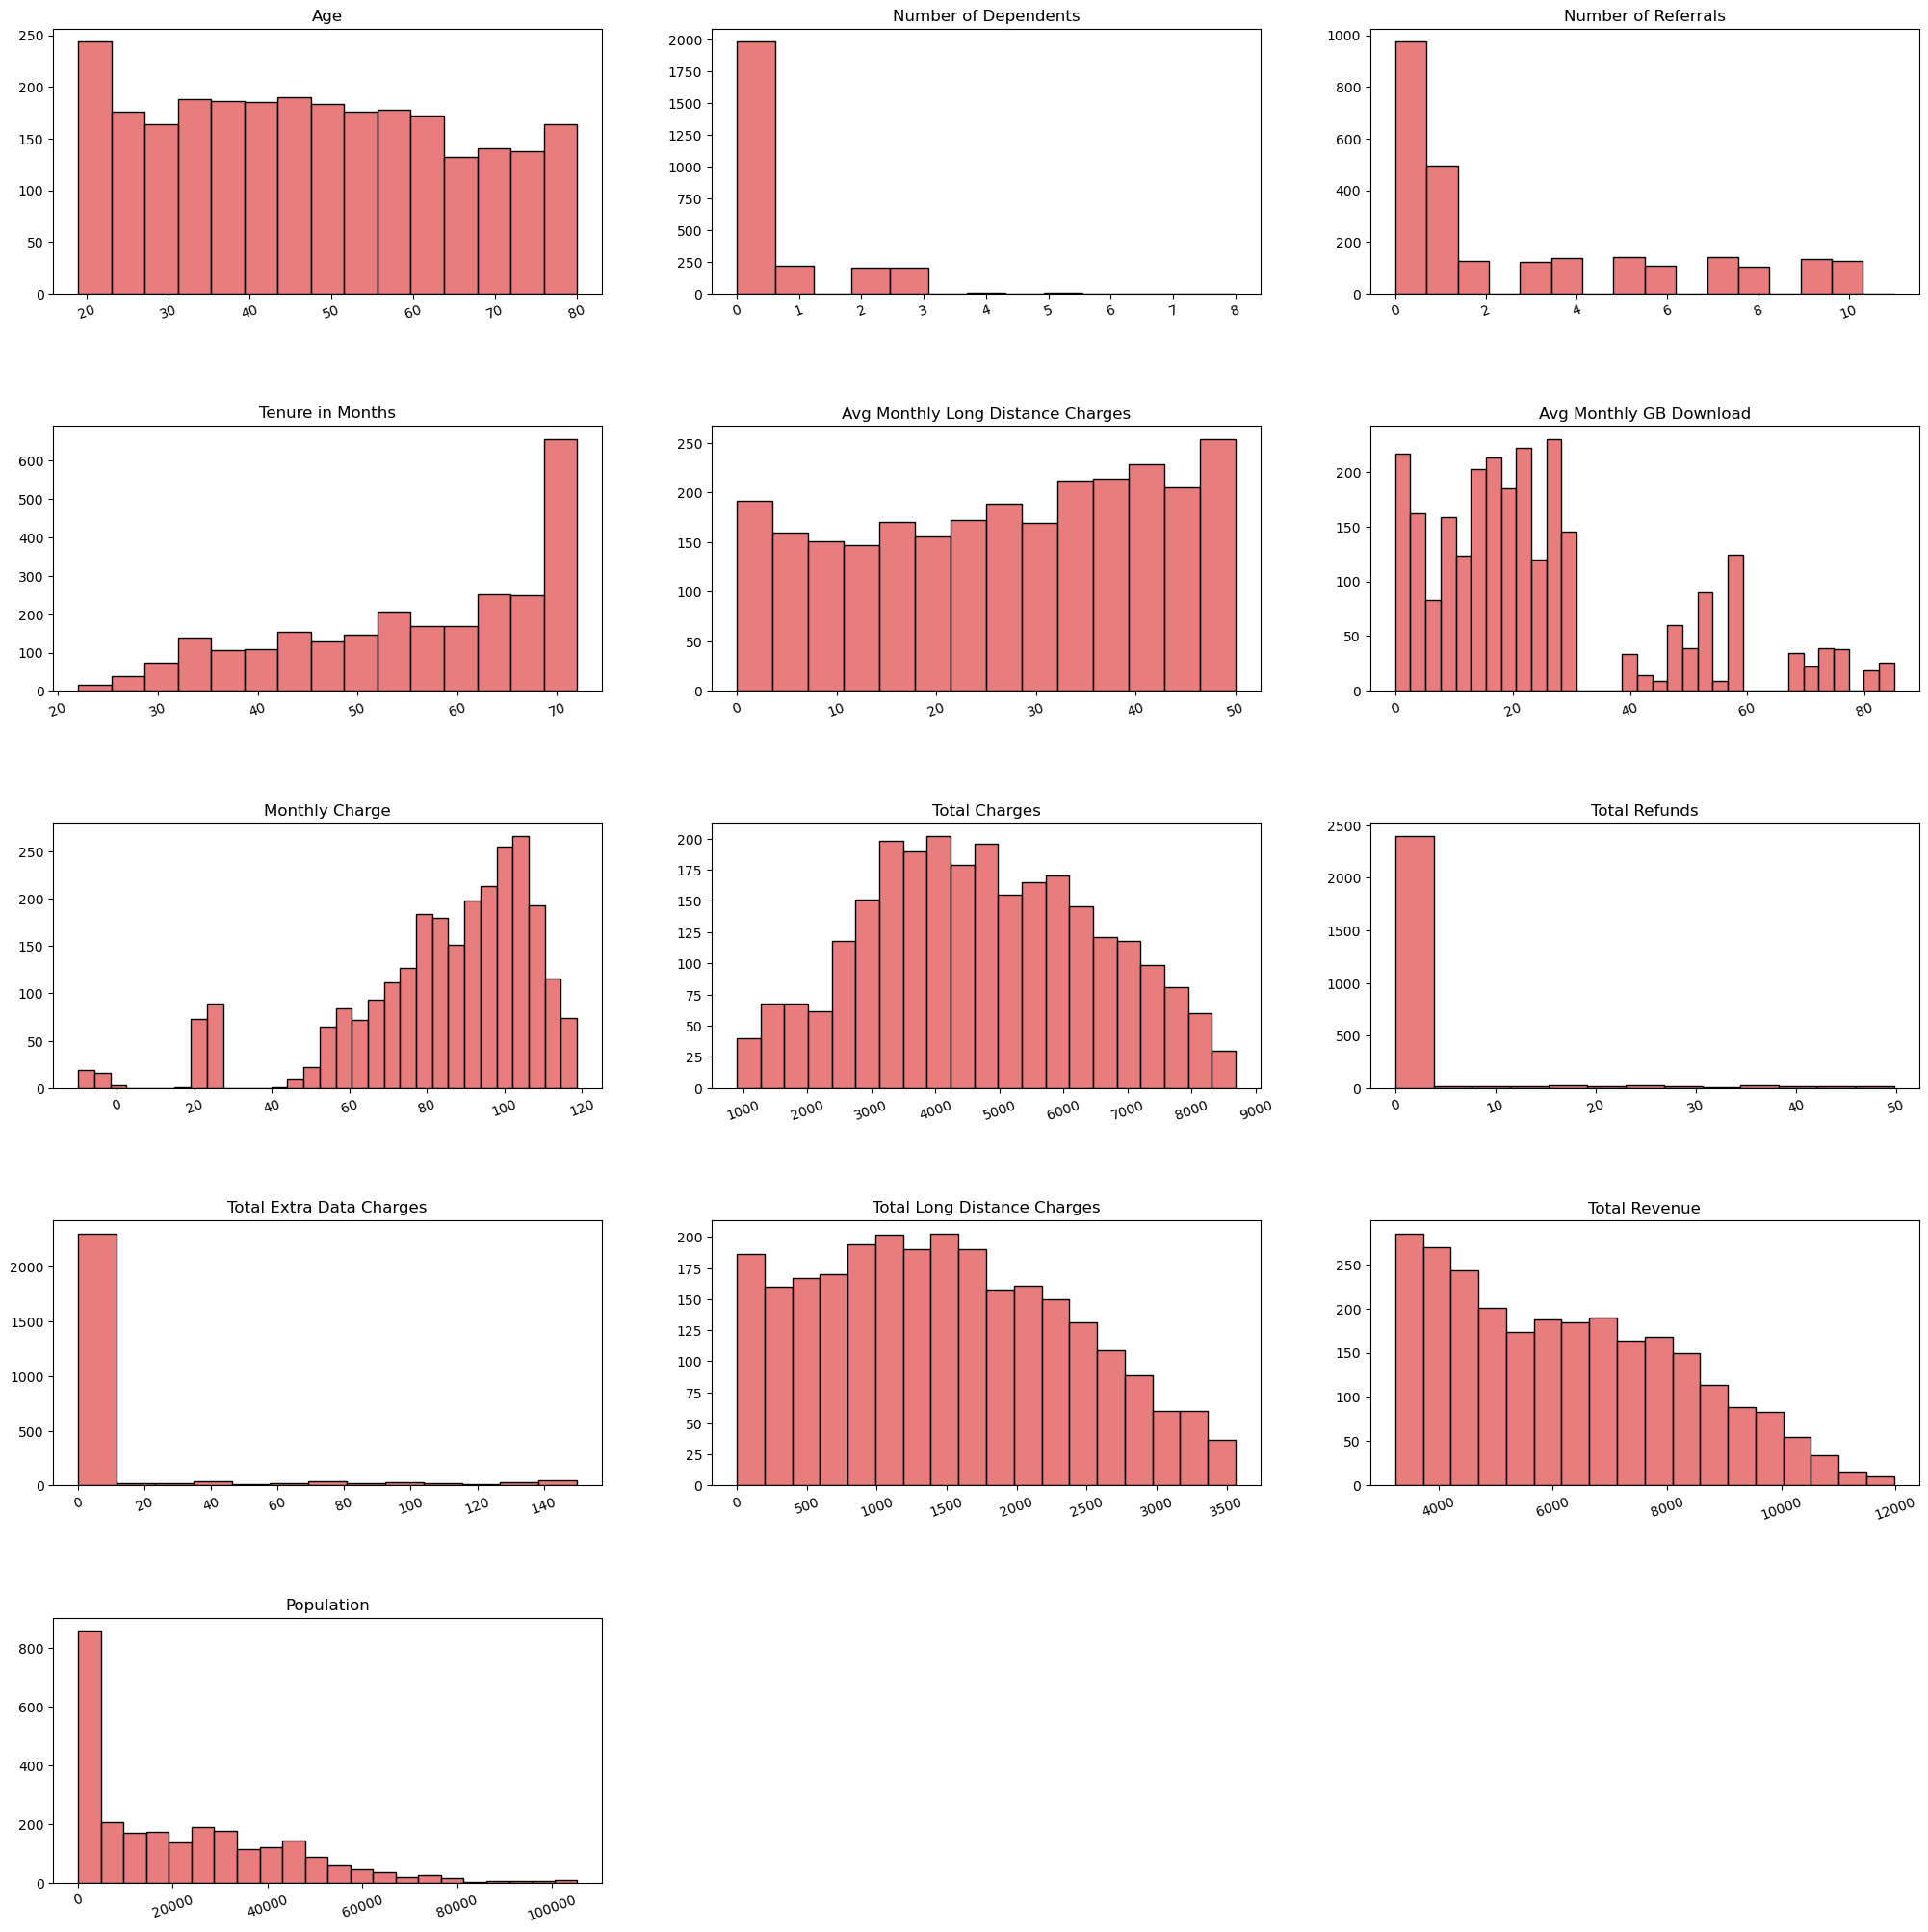

In [46]:
import math

# Calculate the number of rows and columns needed based on the length of num
num_plots = len(num)
num_rows = math.ceil(num_plots / 3)
num_cols = min(num_plots, 3)

# Create the figure with appropriate size and subplot layout
fig = plt.figure(figsize=(25, 25))

# Iterate over num and create subplots
i = 1
for x in num:
    plt.subplot(num_rows, num_cols, i)
    ax = sns.histplot(x=df_high_value[x], color='#E05252')
    ax.set(xlabel=None, ylabel=None)
    plt.title(str(x), loc='center')
    plt.xticks(rotation=20, fontsize=10)
    i += 1

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.5)


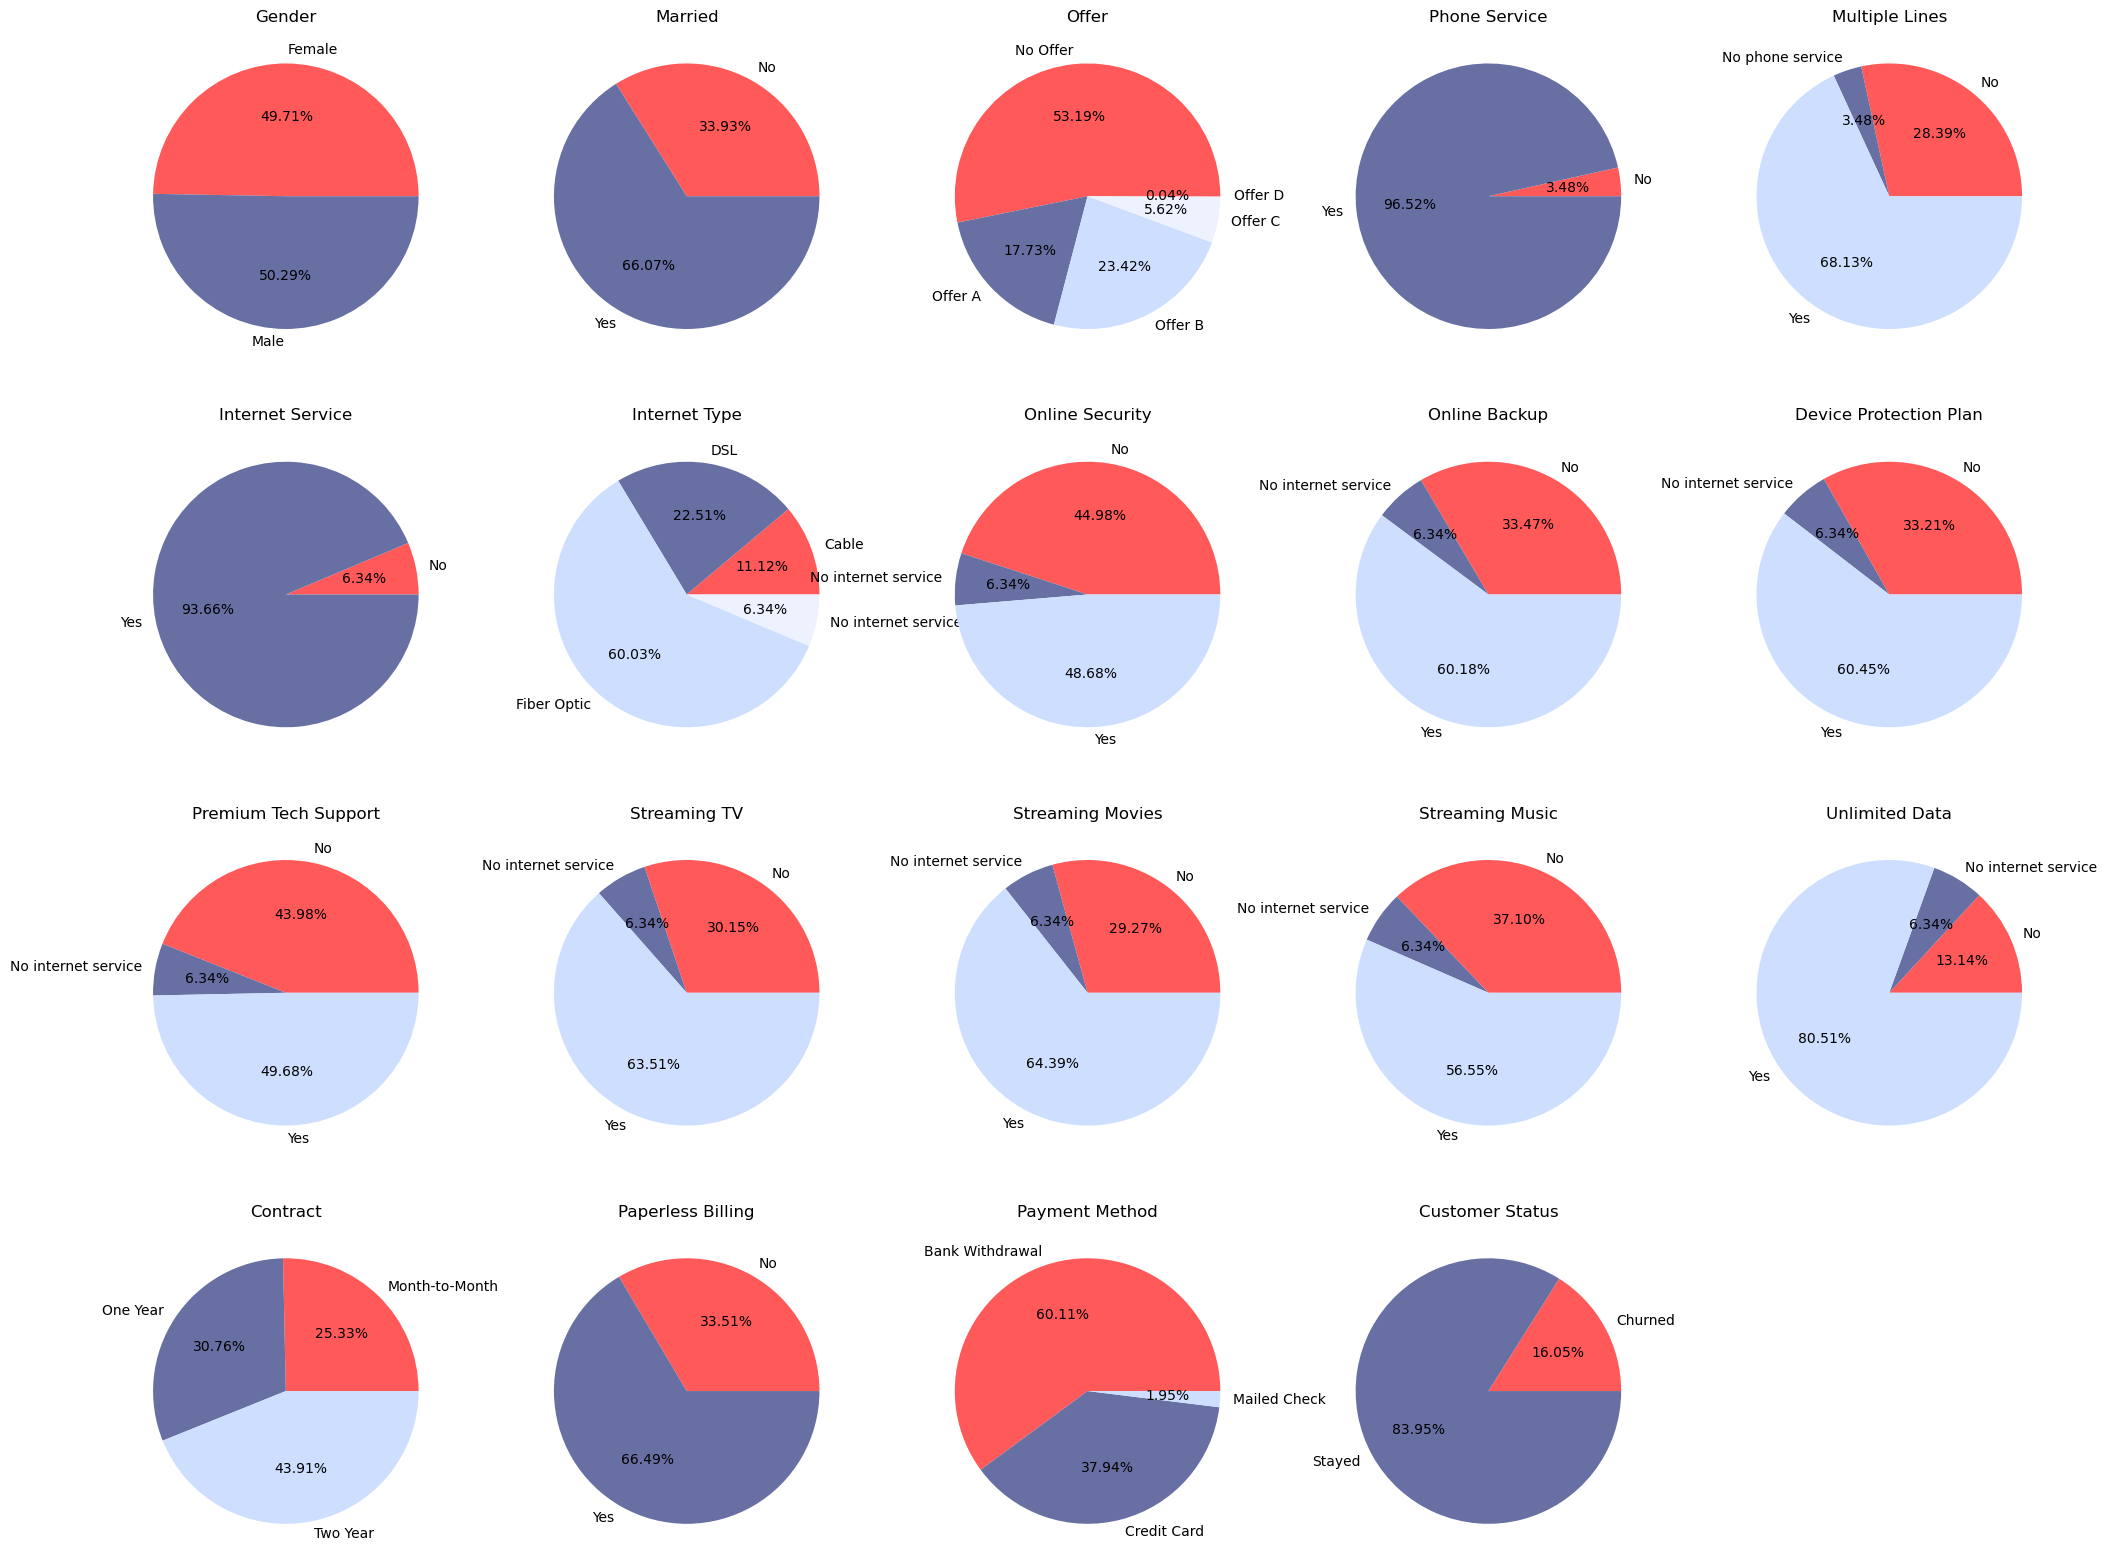

In [47]:
fig = plt.figure(figsize = (25, 25))
i=1
for x in cat:
    plt.subplot(5, 5, i)
    ax = df_high_value.groupby([x]).size().plot(kind = 'pie', autopct = '%.2f%%', colors = ['#FF5959', '#676FA3','#CDDEFF', '#EEF2FF'])
    ax.set(xlabel = None, ylabel = None)
    plt.title(str(x), loc='center')
    i+=1
plt.show()

##### Churn Customers Analysis

In [48]:
df_churned = df.loc[df['Customer Status'] == "Churned"]

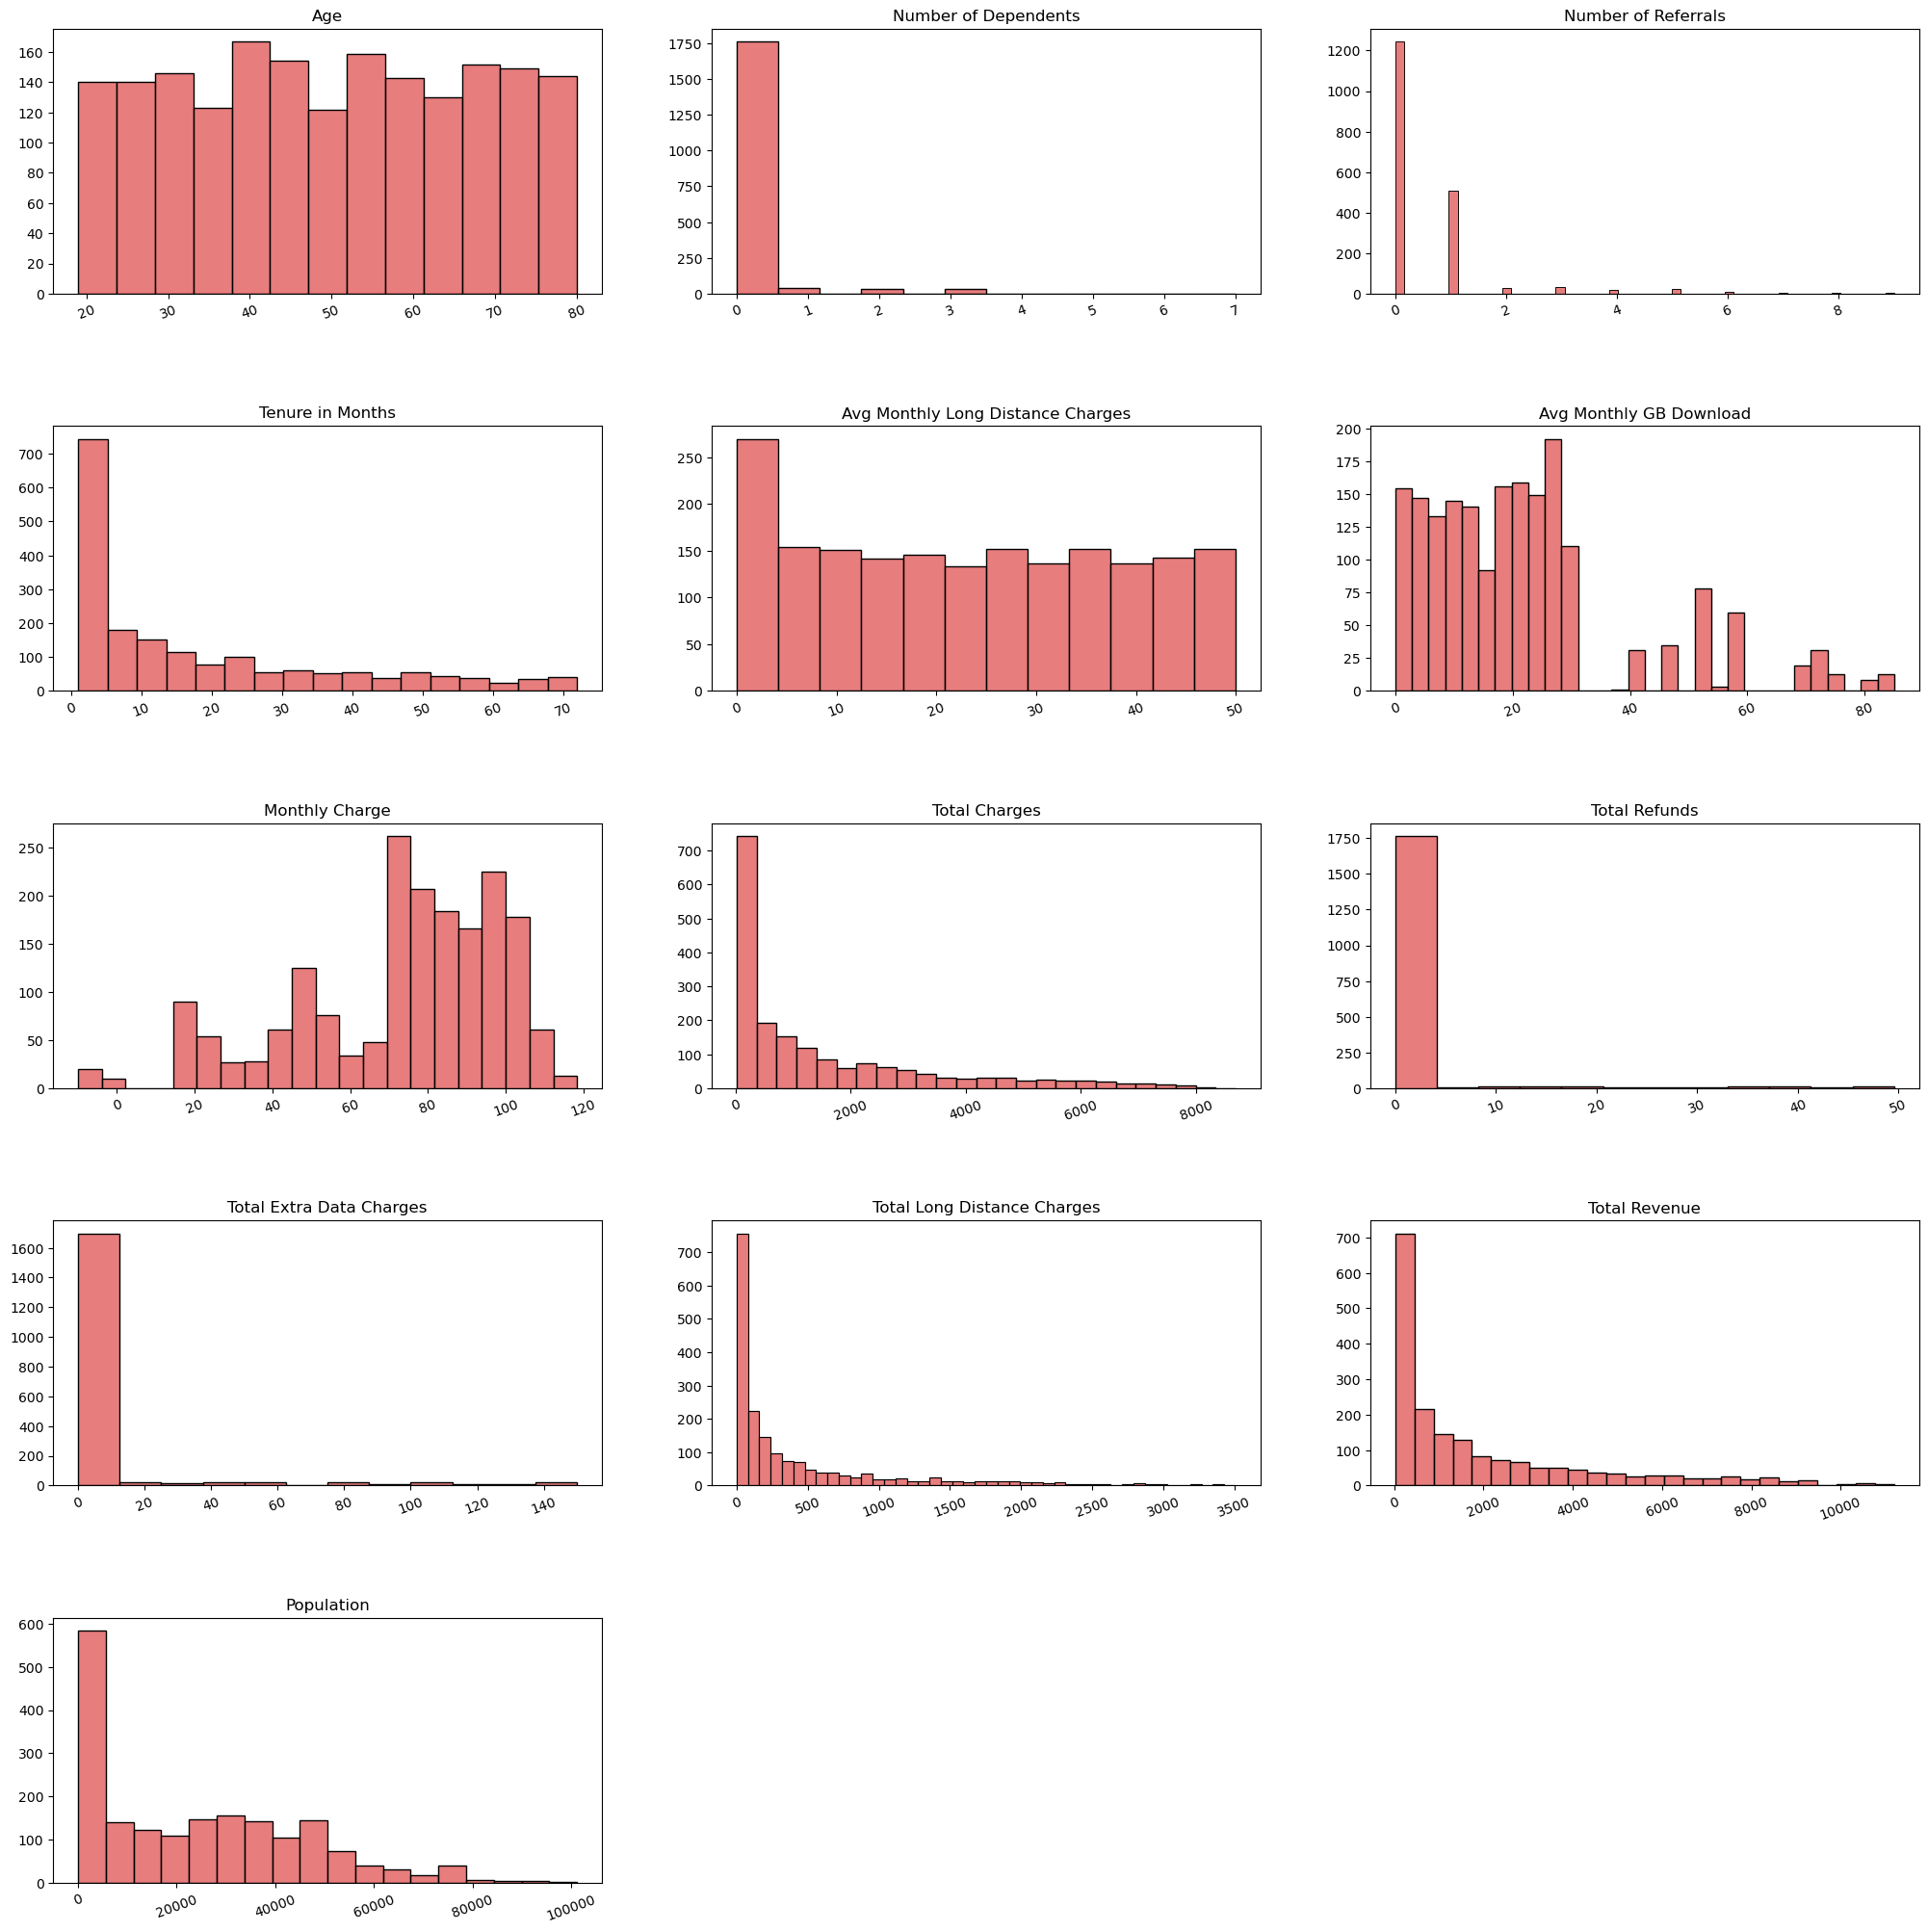

In [49]:
import math

# Calculate the number of rows and columns needed based on the length of num
num_plots = len(num)
num_rows = math.ceil(num_plots / 3)
num_cols = min(num_plots, 3)

# Create the figure with appropriate size and subplot layout
fig = plt.figure(figsize=(25, 25))

# Iterate over num and create subplots
i = 1
for x in num:
    plt.subplot(num_rows, num_cols, i)
    ax = sns.histplot(x=df_churned[x], color='#E05252')
    ax.set(xlabel=None, ylabel=None)
    plt.title(str(x), loc='center')
    plt.xticks(rotation=20, fontsize=10)
    i += 1

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.5)


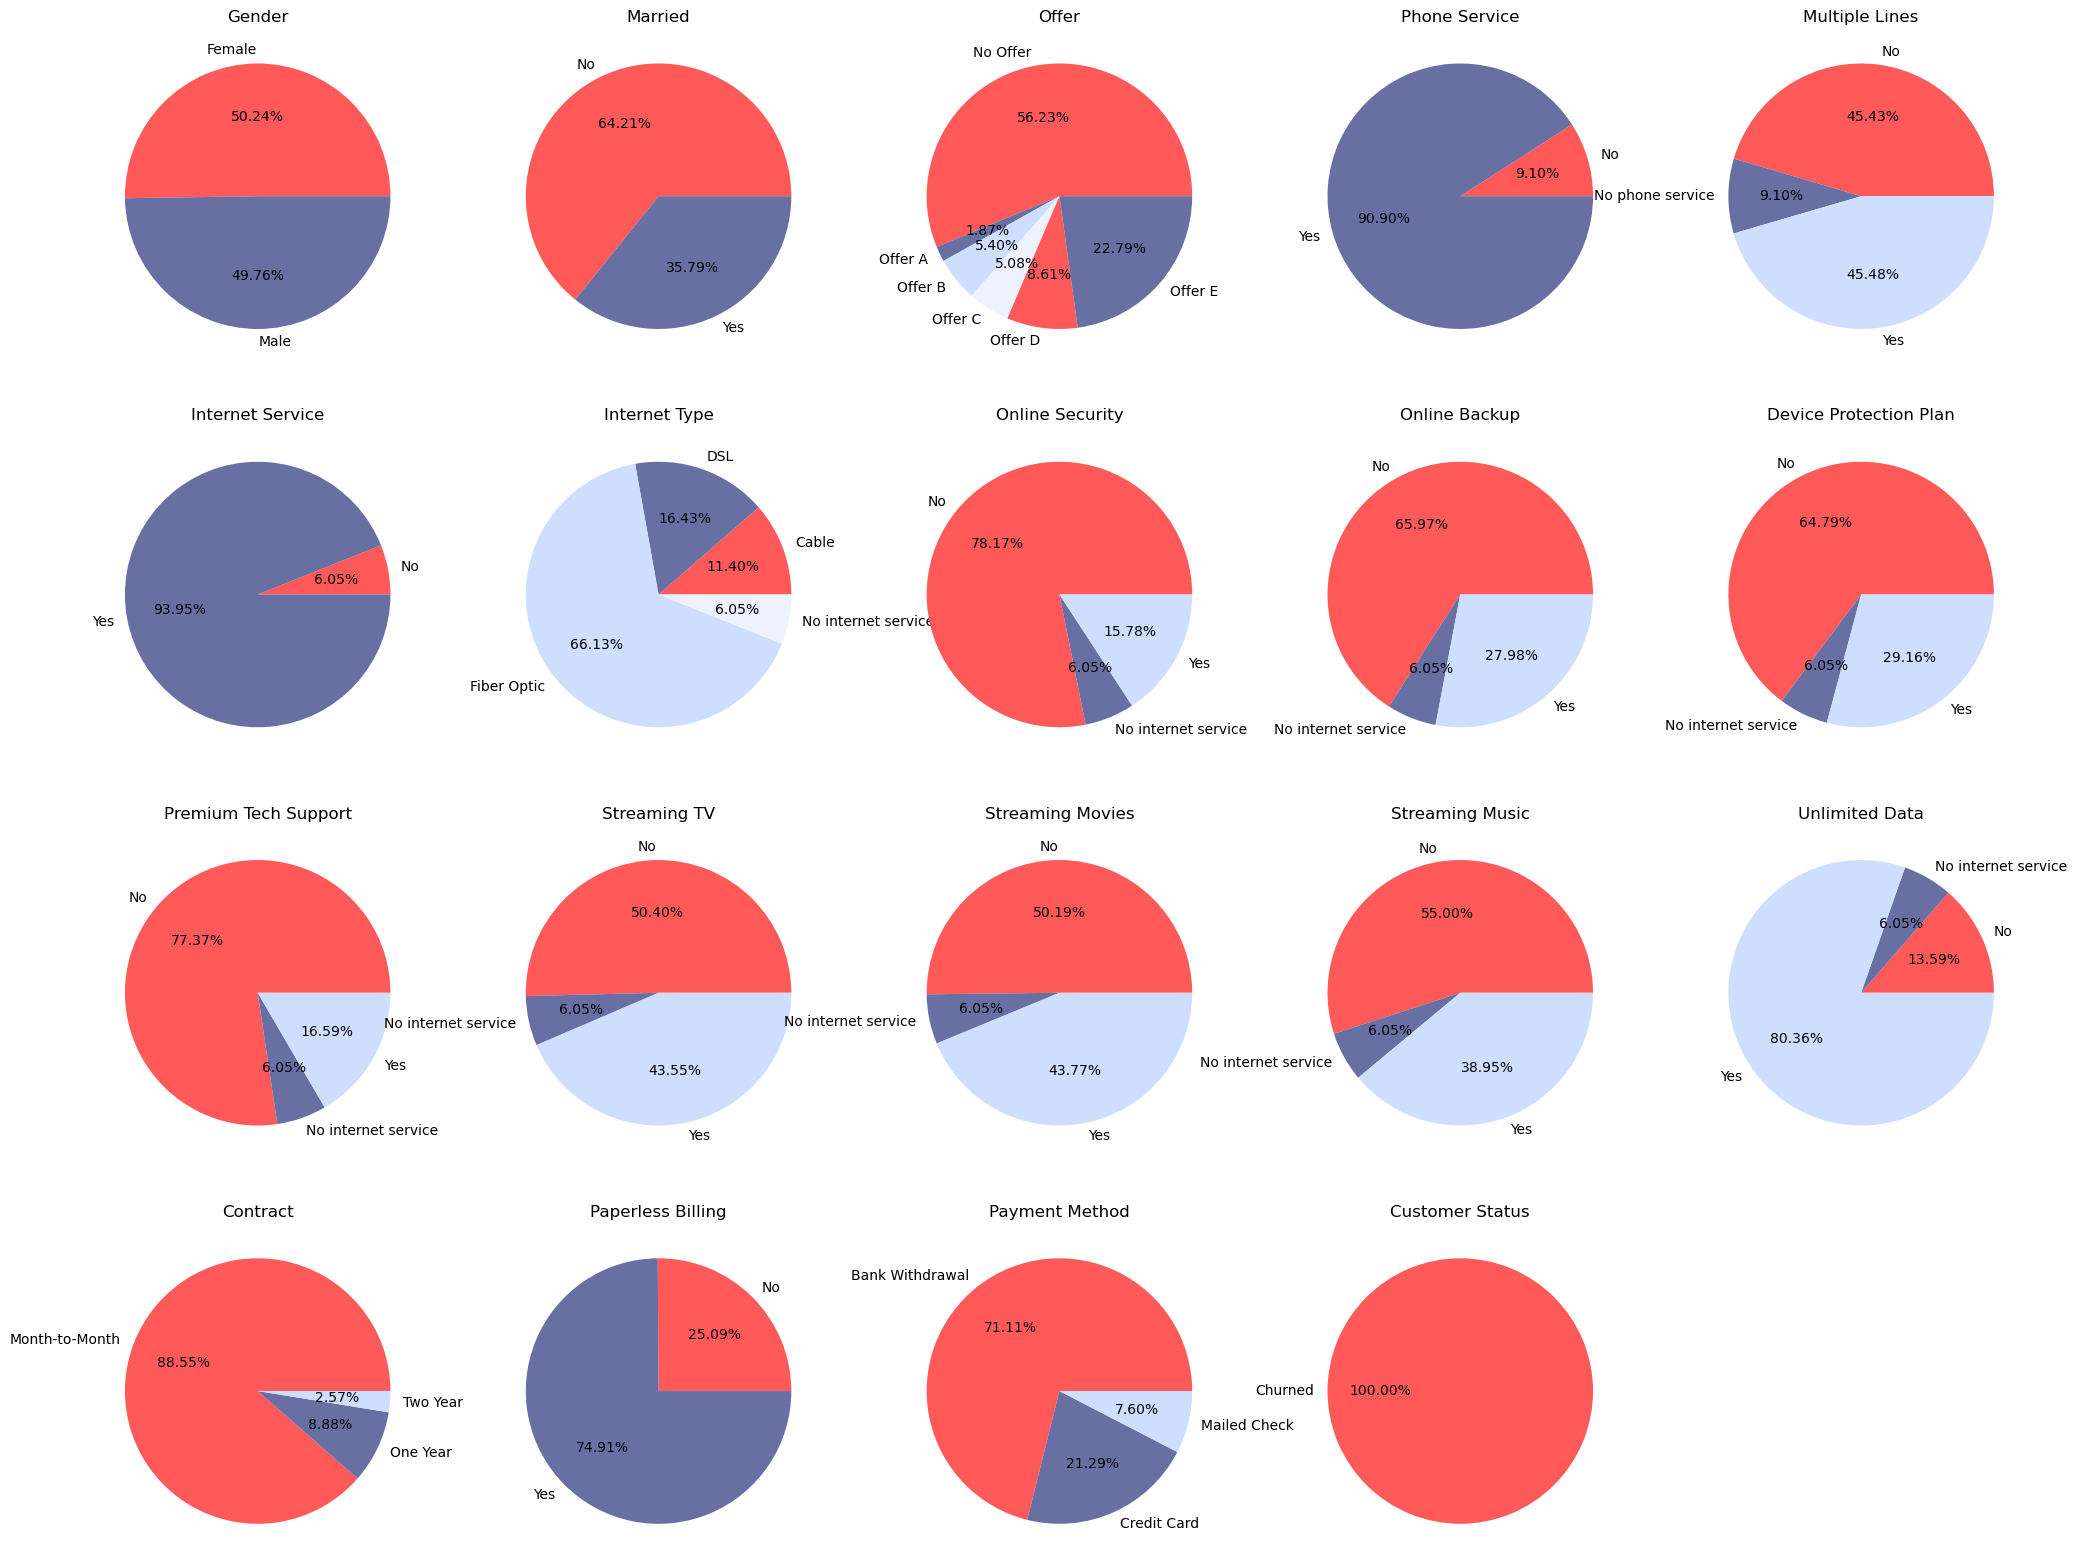

In [50]:
fig = plt.figure(figsize = (25, 25))
i=1
for x in cat:
    plt.subplot(5, 5, i)
    ax = df_churned.groupby([x]).size().plot(kind = 'pie', autopct = '%.2f%%', colors = ['#FF5959', '#676FA3','#CDDEFF', '#EEF2FF'])
    ax.set(xlabel = None, ylabel = None)
    plt.title(str(x), loc='center')
    i+=1
plt.show()

##### Summary (High_Value/Churned) 

1. High Value Customers Profile Recap:

- Approximately 67.73% of these customers are married.
- They have not made a purchase of Offer E.
- More than 50% of this customer segment have subscribed to atleast one of these internet services (backup, security, protection plan, tech support) as well as streaming services (TV, movies, music).
- Out of the 81.66% with long term contracts.

2. Churned Customers Profile Recap:

- Only 35.79% of these customers are married.
- Offer E is the favourite, indicating that the company should review this offer.
- Over 50% of churned customers have not opted for additional internet services or streaming services.
- A significant 88.55% of churned customers prefer a monthly billing cycle.

3. Common Traits:

- There is an even distribution of gender among both customer groups.
- Fiber optic internet service is the most popular among both segments of customers.
- The majority of customers in both groups prefer unlimited data usage.
- A significant portion of customers in both groups prefers receiving paperless billing and making payments through bank withdrawal.

In [51]:
# These features will hinder the model's ability 
df = df.drop(columns=['Churn Category', 'Churn Reason','High Value'])

## Feature Engineering 

In [52]:
le = LabelEncoder()

df1 = df.copy(deep = True)
text_data_features = [i for i in list(df.columns) if i not in list(df.describe().columns)]

print('Label Encoder Transformation')
for i in text_data_features :
    df1[i] = le.fit_transform(df1[i])
    print(i,' : ',df1[i].unique(),' = ',le.inverse_transform(df1[i].unique()))

Label Encoder Transformation
Gender  :  [0 1]  =  ['Female' 'Male']
Married  :  [1 0]  =  ['Yes' 'No']
City  :  [346 368 222 ... 477 163 597]  =  ['Frazier Park' 'Glendale' 'Costa Mesa' ... 'Kirkwood' 'Carpinteria'
 'Meadow Valley']
Offer  :  [0 5 4 1 2 3]  =  ['No Offer' 'Offer E' 'Offer D' 'Offer A' 'Offer B' 'Offer C']
Phone Service  :  [1 0]  =  ['Yes' 'No']
Multiple Lines  :  [0 2 1]  =  ['No' 'Yes' 'No phone service']
Internet Service  :  [1 0]  =  ['Yes' 'No']
Internet Type  :  [0 2 1 3]  =  ['Cable' 'Fiber Optic' 'DSL' 'No internet service']
Online Security  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
Online Backup  :  [2 0 1]  =  ['Yes' 'No' 'No internet service']
Device Protection Plan  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
Premium Tech Support  :  [2 0 1]  =  ['Yes' 'No' 'No internet service']
Streaming TV  :  [2 0 1]  =  ['Yes' 'No' 'No internet service']
Streaming Movies  :  [0 2 1]  =  ['No' 'Yes' 'No internet service']
Streaming Music  :  [0 2 1]  =  ['

The Customer ID column is not required for prediction. Also, the geographical features such as City, Zip Code, Latitude and Longitude do not effect our target variable much as we have seen during the EDA stage.

In [53]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6589 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             6589 non-null   int32  
 1   Age                                6589 non-null   int64  
 2   Married                            6589 non-null   int32  
 3   Number of Dependents               6589 non-null   int64  
 4   City                               6589 non-null   int32  
 5   Number of Referrals                6589 non-null   int64  
 6   Tenure in Months                   6589 non-null   int64  
 7   Offer                              6589 non-null   int32  
 8   Phone Service                      6589 non-null   int32  
 9   Avg Monthly Long Distance Charges  6589 non-null   float64
 10  Multiple Lines                     6589 non-null   int32  
 11  Internet Service                   6589 non-null   int32  
 1

## Model Building and Evaluation¶ 

In [54]:

X = df1.drop(columns=['Customer Status'])
y = df1['Customer Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=41)


In [55]:
print(X.shape)
print(y.shape)

(6589, 32)
(6589,)


In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=41)

##### Applying SMOTE:

In [57]:
smote = SMOTE(random_state=50)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

##### Catboost: 

In [59]:
import pickle
# Initialize lists to store evaluation metrics
accuracy = []
recall = []
roc_auc = []
precision = []
f1 = []
model_names = []

# Define the parameter grid for GridSearchCV
params_grid = {
    'iterations': [500, 1000],
    'learning_rate': [0.01, 0.1],
    'depth': [4, 8],
    'l2_leaf_reg': [1, 3],
    'bootstrap_type': ['Bayesian', 'Bernoulli'],
    'random_strength': [1, 2]
}

# Initialize the CatBoost classifier
catboost_classifier = CatBoostClassifier(verbose=False, random_state=0)

# Perform grid search with 2-fold cross-validation
grid_search = GridSearchCV(estimator=catboost_classifier, param_grid=params_grid, cv=2, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_smote, y_train_smote)

# Get the best estimator
best_catboost = grid_search.best_estimator_

# Predict on the test set
y_pred = best_catboost.predict(X_test)

# Calculate evaluation metrics
accuracy.append(round(accuracy_score(y_test, y_pred), 4))
recall.append(round(recall_score(y_test, y_pred), 4))
precision.append(round(precision_score(y_test, y_pred), 4))
f1.append(round(f1_score(y_test, y_pred), 4))

# Save the best trained model using pickle
with open('best_catboost_model.pkl', 'wb') as f:
    pickle.dump(best_catboost, f)

# Define model names
model_names = ['Catboost_default']

# Create a DataFrame with evaluation metrics
result_df1 = pd.DataFrame({
    'Accuracy': accuracy,
    'Recall': recall,
    'F1_score': f1,
    'Precision': precision
}, index=model_names)

# Print the DataFrame with evaluation metrics
result_df1


KeyboardInterrupt: 

In [ ]:
# Define a custom colormap
custom_cmap = plt.cm.get_cmap('Greens')

# Plot the confusion matrix with the custom colormap
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(best_catboost, X_test, y_test, cmap=custom_cmap, ax=ax, 
                                      display_labels=['Churned', 'Not Churned'])

# Optionally, add titles or labels here
ax.set_title('Confusion Matrix')
plt.show()

##### XGboost Classifier: 

In [ ]:
# Lists to store the evaluation metrics
accuracy = []
recall = []
f1 = []
precision = []
model_names = []

# Define the parameter grid for GridSearchCV
params_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'min_child_weight': [3, 5],
    'gamma': [0.1, 0.2],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [1, 2]
}

# Initialize the XGBoost classifier
xgb_classifier = XGBClassifier(random_state=0, use_label_encoder=False, eval_metric='logloss')

# Perform grid search with 2-fold cross-validation
grid_search = GridSearchCV(estimator=xgb_classifier, param_grid=params_grid, cv=2, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_smote, y_train_smote)

# Get the best estimator
best_xgb = grid_search.best_estimator_

# Predict on the test set
y_pred = best_xgb.predict(X_test)

# Calculate the evaluation metrics
accuracy.append(round(accuracy_score(y_test, y_pred), 4))
recall.append(round(recall_score(y_test, y_pred), 4))
precision.append(round(precision_score(y_test, y_pred), 4))
f1.append(round(f1_score(y_test, y_pred), 4))

# Save the best trained model using pickle
with open('best_xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

# Define model name
model_names = ['XGBoost_default']

# Create a DataFrame to store the results
result_df2 = pd.DataFrame({
    'Accuracy': accuracy,
    'Recall': recall,
    'F1_score': f1,
    'Precision': precision
}, index=model_names)

result_df2


In [ ]:
# Define a custom colormap
custom_cmap = plt.cm.get_cmap('Greens')  # Change the colormap to 'Greens'

# Plot the confusion matrix with the custom colormap
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, cmap=custom_cmap, ax=ax,
                                      display_labels=['Churned', 'Not Churned'])

# Optionally, add titles or labels here
ax.set_title('Confusion Matrix')
plt.show()

##### Decission Tree: 

In [ ]:
# Initialize lists to store evaluation metrics
accuracy = []
recall = []
f1 = []
precision = []
model_names = []

# Initialize DecisionTreeClassifier
dtc = DecisionTreeClassifier()

# Define the parameter grid for GridSearchCV
params_grid = {
    'criterion': ['gini', 'entropy'],
    'max_leaf_nodes': range(1, 20)
}

# Perform grid search with 2-fold cross-validation
grid_search = GridSearchCV(estimator=dtc, param_grid=params_grid, cv=2)
grid_search.fit(X_train_smote, y_train_smote)

# Get the best estimator
best_dtc = grid_search.best_estimator_

# Predict on the test set
y_pred = best_dtc.predict(X_test)

# Calculate evaluation metrics
accuracy.append(round(accuracy_score(y_test, y_pred), 4))
recall.append(round(recall_score(y_test, y_pred), 4))
precision.append(round(precision_score(y_test, y_pred), 4))
f1.append(round(f1_score(y_test, y_pred), 4))

# Save the best trained model using pickle
with open('best_dtc_model.pkl', 'wb') as f:
    pickle.dump(best_dtc, f)

# Define model name
model_names = ['DecisionTree_Default']

# Create a DataFrame with evaluation metrics
result_df3 = pd.DataFrame({
    'Accuracy': accuracy,
    'Recall': recall,
    'F1_score': f1,
    'Precision': precision
}, index=model_names)

# Print the DataFrame with evaluation metrics
result_df3


In [ ]:
#Define a custom colormap
custom_cmap = plt.cm.get_cmap('Greens')  # Change the colormap to 'Greens'

# Plot the confusion matrix with the custom colormap
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(best_dtc, X_test, y_test, cmap=custom_cmap, ax=ax,
                                      display_labels=['Churned', 'Not Churned'])

# Optionally, add titles or labels
ax.set_title('Confusion Matrix')
plt.show()

##### Random Forest: 

In [ ]:
# Initialize lists to store evaluation metrics
accuracy = []
recall = []
f1 = []
precision = []
model_names = []

# Define the parameter grid for GridSearchCV
params_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=0)

# Perform grid search with 2-fold cross-validation
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=params_grid, cv=2, n_jobs=-1)
grid_search.fit(X_train_smote, y_train_smote)

# Get the best estimator
best_rf = grid_search.best_estimator_

# Predict on the test set
y_pred = best_rf.predict(X_test)

# Calculate the evaluation metrics
accuracy.append(round(accuracy_score(y_test, y_pred), 4))
recall.append(round(recall_score(y_test, y_pred), 4))
precision.append(round(precision_score(y_test, y_pred), 4))
f1.append(round(f1_score(y_test, y_pred), 4))

# Save the best trained model using pickle
with open('best_rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

# Define model name
model_names = ['Randomforest_Default']

# Create a DataFrame to store the results
result_df4 = pd.DataFrame({
    'Accuracy': accuracy,
    'Recall': recall,
    'F1_score': f1,
    'Precision': precision
}, index=model_names)

result_df4


In [ ]:
# Define a custom colormap
custom_cmap = plt.cm.get_cmap('Greens')  # Change the colormap to 'Greens'

# Plot the confusion matrix with the custom colormap
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap=custom_cmap, ax=ax,
                                      display_labels=['Churned', 'Not Churned'])

# Optionally, add titles or labels
ax.set_title('Confusion Matrix')
plt.show()

In [ ]:
# Compute ROC curve and ROC AUC for each model
fpr_catboost, tpr_catboost, _ = roc_curve(y_test, best_catboost.predict_proba(X_test)[:, 1])
roc_auc_catboost = roc_auc_score(y_test, best_catboost.predict_proba(X_test)[:, 1])

fpr_xgboost, tpr_xgboost, _ = roc_curve(y_test, best_xgb.predict_proba(X_test)[:, 1])
roc_auc_xgboost = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1])

fpr_dtc, tpr_dtc, _ = roc_curve(y_test, best_dtc.predict_proba(X_test)[:, 1])
roc_auc_dtc = roc_auc_score(y_test, best_dtc.predict_proba(X_test)[:, 1])

fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
roc_auc_rf = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

# Plot ROC curve for each model
plt.figure(figsize=(10, 6))
plt.plot(fpr_catboost, tpr_catboost, color='blue', label=f'CatBoost (AUC = {roc_auc_catboost:.4f})')
plt.plot(fpr_xgboost, tpr_xgboost, color='red', label=f'XGBoost (AUC = {roc_auc_xgboost:.4f})')
plt.plot(fpr_dtc, tpr_dtc, color='green', label=f'DecisionTree (AUC = {roc_auc_dtc:.4f})')
plt.plot(fpr_rf, tpr_rf, color='orange', label=f'RandomForest (AUC = {roc_auc_rf:.4f})')

# Plot ROC curve for random guessing
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Different Models')
plt.legend()
plt.grid(True)
plt.show()


### With feature selection 

In [ ]:
# Calculate correlations with 'Customer Status'
correlations = df1.corr()['Customer Status'].drop('Customer Status')  # Exclude self-correlation

# Sortting correlations by absolute value to get the top 12 features
top_12_features = correlations.abs().sort_values(ascending=False).head(12)

# Plot graph
plt.figure(figsize=(10, 6))
sns.barplot(x=top_12_features.values, y=top_12_features.index, palette="viridis")
plt.title('Top 12 Features Correlated with Customer Status')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

#Chaning array to list
features_list = top_12_features.index.tolist()

In [ ]:
#Splitting for train test

X = df1[features_list]  # Features
y = df1['Customer Status']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

# Apply SMOTE to the training data
smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
# Initialize lists to store evaluation metrics
accuracy = []
recall = []
f1 = []
precision = []
model_names = []

# Initialize the CatBoost classifier with given parameters
catboost_base = CatBoostClassifier(iterations=1000, learning_rate=0.1, bootstrap_type='Bayesian', verbose=False, random_state=0)

# Train the model
catboost_base.fit(X_train_smote, y_train_smote, eval_set=(X_test, y_test))
y_pred = catboost_base.predict(X_test)

# Calculate evaluation metrics
accuracy.append(round(accuracy_score(y_test, y_pred), 4))
recall.append(round(recall_score(y_test, y_pred), 4))
precision.append(round(precision_score(y_test, y_pred), 4))
f1.append(round(f1_score(y_test, y_pred), 4))


# Define model names
model_names = ['Catboost_Feature']

# Create a DataFrame with evaluation metrics
result_df1 = pd.DataFrame({
    'Accuracy': accuracy,
    'Recall': recall,
    'F1_score': f1,
    'Precision': precision
}, index=model_names)

# Print the DataFrame with evaluation metrics
result_df1


In [ ]:
# Lists to store the evaluation metrics
accuracy = []
recall = []
f1 = []
precision = []
model_names = []

# Initialize the XGBoost classifier with given parameters
xgbc_base = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=0)

# Train the model
xgbc_base.fit(X_train_smote, y_train_smote)

# Predict on the test set
y_pred = xgbc_base.predict(X_test)

# Append the evaluation metrics to their respective lists
accuracy.append(round(accuracy_score(y_test, y_pred), 4))
recall.append(round(recall_score(y_test, y_pred), 4))
precision.append(round(precision_score(y_test, y_pred), 4))
f1.append(round(f1_score(y_test, y_pred), 4))

# Define model name
model_names = ['XGBoost_Feature']

# Create a DataFrame to store the results
result_df2 = pd.DataFrame({
    'Accuracy': accuracy,
    'Recall': recall,
    'F1_score': f1,
    'Precision': precision
}, index=model_names)

result_df2


In [ ]:
# Initialize lists to store evaluation metrics
accuracy = []
recall = []
f1 = []
precision = []
model_names = []

# Initialize DecisionTreeClassifier
dtc = DecisionTreeClassifier()

# Define the parameter grid for GridSearchCV
params_grid = {
    'criterion': ['gini', 'entropy'],
    'max_leaf_nodes': range(1, 20)
}

# Perform grid search with 2-fold cross-validation
grid_search = GridSearchCV(estimator=dtc, param_grid=params_grid, cv=2)
grid_search.fit(X_train_smote, y_train_smote)

# Get the best estimator
best_dtc = grid_search.best_estimator_

# Predict on the test set
y_pred = best_dtc.predict(X_test)

# Calculate evaluation metrics
accuracy.append(round(accuracy_score(y_test, y_pred), 4))
recall.append(round(recall_score(y_test, y_pred), 4))
precision.append(round(precision_score(y_test, y_pred), 4))
f1.append(round(f1_score(y_test, y_pred), 4))

# Define model name
model_names = ['DecisionTree_Feature']

# Create a DataFrame with evaluation metrics
result_df3 = pd.DataFrame({
    'Accuracy': accuracy,
    'Recall': recall,
    'F1_score': f1,
    'Precision': precision
}, index=model_names)

# Print the DataFrame with evaluation metrics
result_df3


In [ ]:
# Initialize lists to store evaluation metrics
accuracy = []
recall = []
f1 = []
precision = []
model_names = []


# Define the parameter grid for GridSearchCV
params_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=0)

# Perform grid search with 2-fold cross-validation
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=params_grid, cv=2, n_jobs=-1)
grid_search.fit(X_train_smote, y_train_smote)

# Get the best estimator
best_rf = grid_search.best_estimator_

# Predict on the test set
y_pred = best_rf.predict(X_test)

# Calculate the evaluation metrics
accuracy.append(round(accuracy_score(y_test, y_pred), 4))
recall.append(round(recall_score(y_test, y_pred), 4))
precision.append(round(precision_score(y_test, y_pred), 4))
f1.append(round(f1_score(y_test, y_pred), 4))


# Define model name
model_names = ['Randomforest_Feature']

# Create a DataFrame to store the results
result_df4 = pd.DataFrame({
    'Accuracy': accuracy,
    'Recall': recall,
    'F1_score': f1,
    'Precision': precision
}, index=model_names)

result_df4


##### Note: 
- After feature selection the accuracy didn't seems improving